Class Weights: [  0.25563892  19.93170374  31.05530019 170.6293415 ]
Epoch 1/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7496 - loss: 0.8144

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


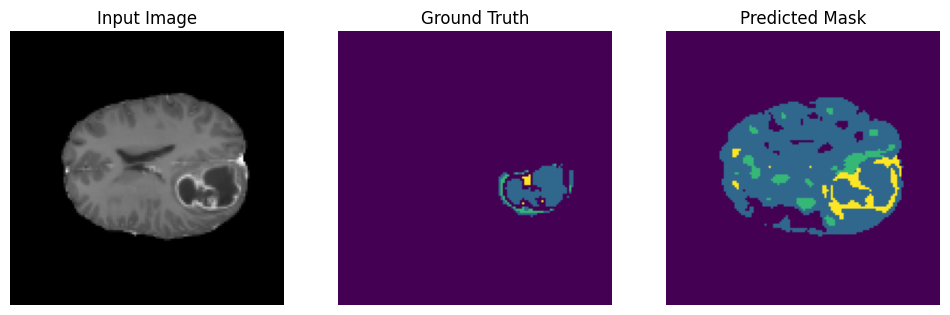

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 362s 129ms/step - accuracy: 0.7496 - loss: 0.8144 - val_accuracy: 0.8262 - val_loss: 0.4803
Epoch 2/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8630 - loss: 0.4800

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


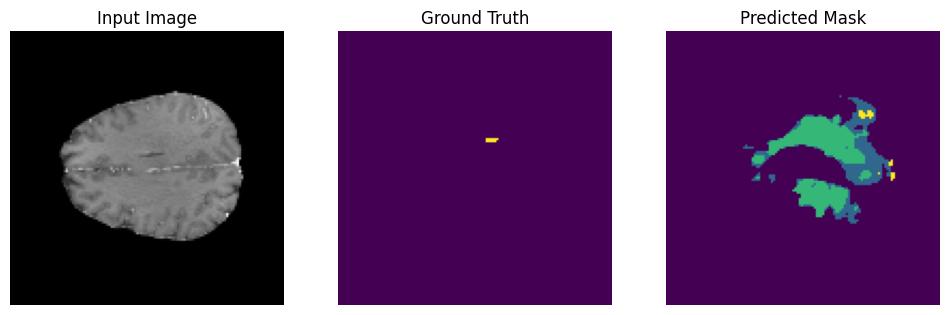

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 353s 129ms/step - accuracy: 0.8630 - loss: 0.4800 - val_accuracy: 0.9019 - val_loss: 0.4053
Epoch 3/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9023 - loss: 0.4046

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


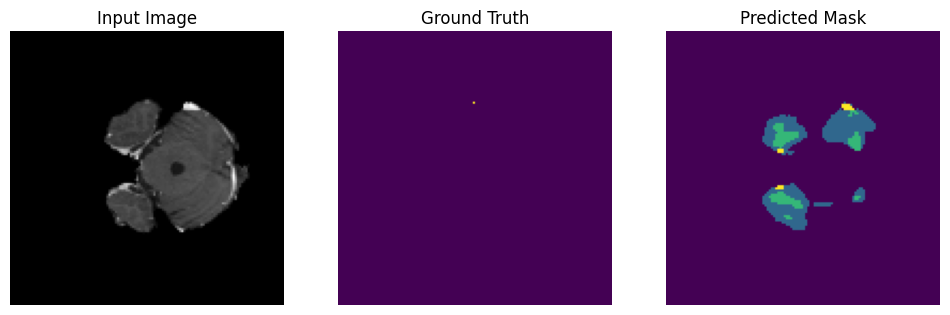

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 379s 138ms/step - accuracy: 0.9023 - loss: 0.4046 - val_accuracy: 0.8978 - val_loss: 0.3865
Epoch 4/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9125 - loss: 0.3830

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


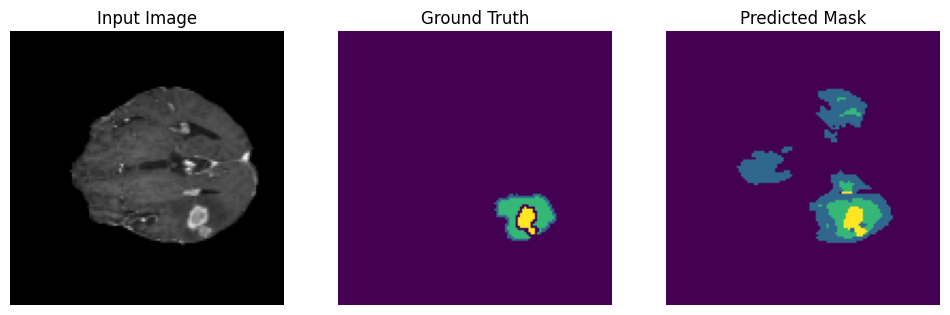

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 376s 137ms/step - accuracy: 0.9125 - loss: 0.3830 - val_accuracy: 0.9301 - val_loss: 0.3610
Epoch 5/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9182 - loss: 0.3573

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


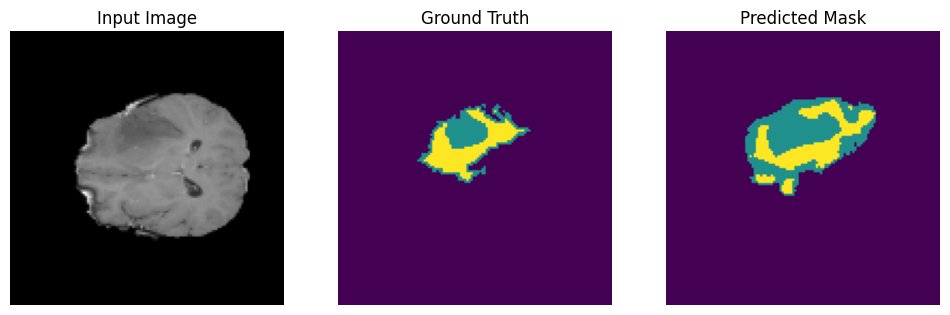

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 378s 138ms/step - accuracy: 0.9182 - loss: 0.3573 - val_accuracy: 0.9209 - val_loss: 0.3464
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


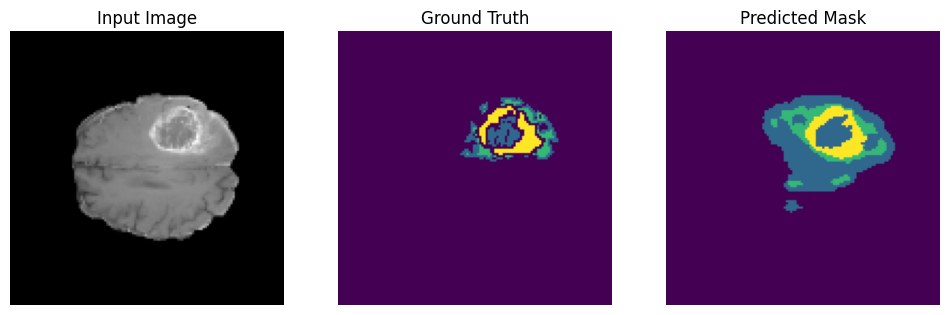

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 377s 138ms/step - accuracy: 0.9240 - loss: 0.3357 - val_accuracy: 0.9329 - val_loss: 0.3496
Epoch 7/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9281 - loss: 0.3196

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


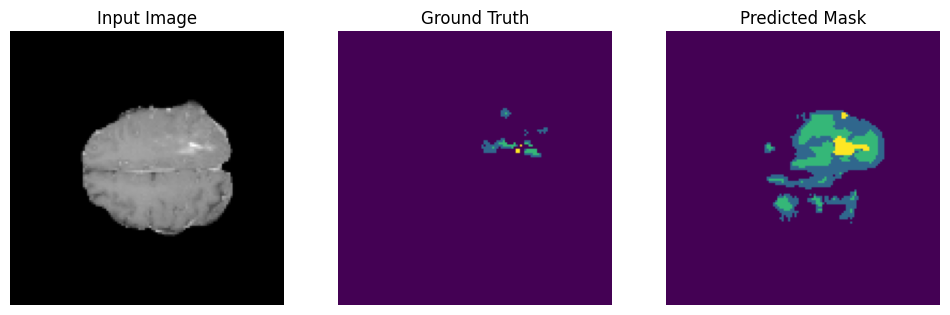

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 383s 140ms/step - accuracy: 0.9281 - loss: 0.3196 - val_accuracy: 0.9176 - val_loss: 0.3278
Epoch 8/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9297 - loss: 0.3135

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


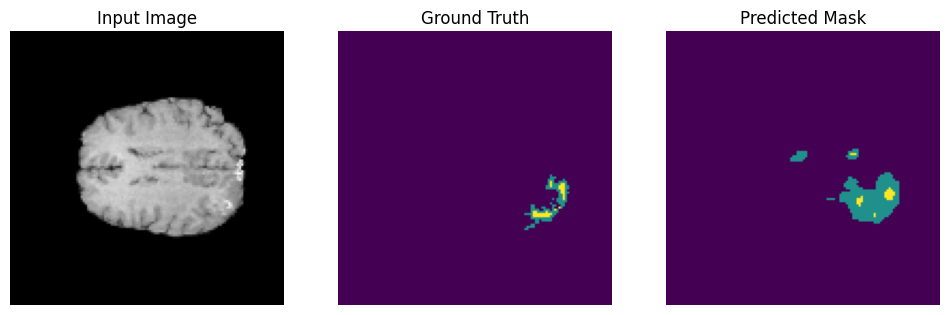

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 382s 140ms/step - accuracy: 0.9297 - loss: 0.3135 - val_accuracy: 0.9242 - val_loss: 0.3110
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


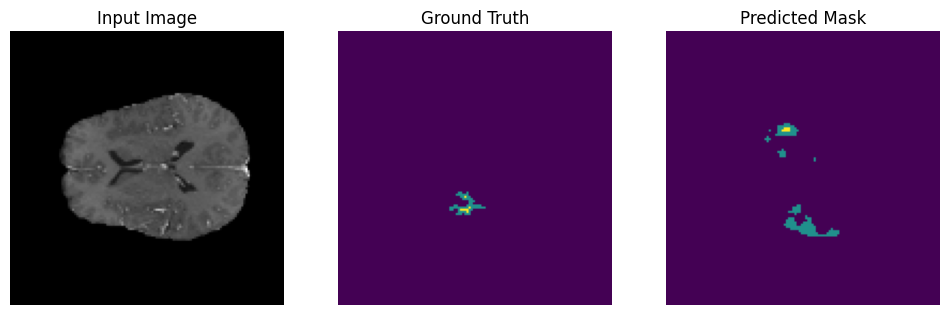

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 383s 140ms/step - accuracy: 0.9335 - loss: 0.2974 - val_accuracy: 0.9420 - val_loss: 0.3168
Epoch 10/10
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9349 - loss: 0.2950

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


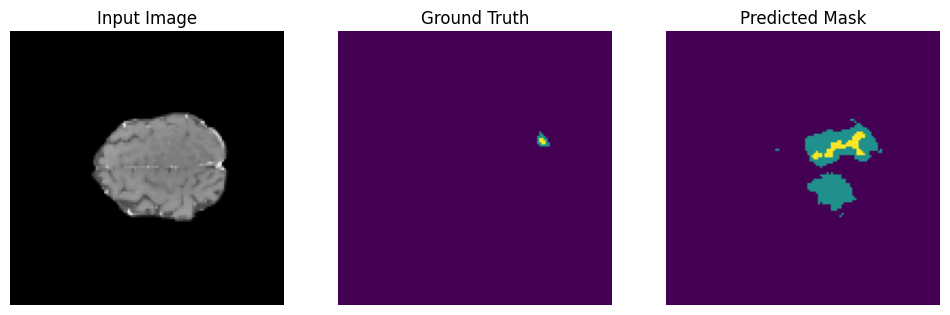

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 390s 142ms/step - accuracy: 0.9349 - loss: 0.2950 - val_accuracy: 0.9372 - val_loss: 0.3048


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# -------------------------
# 1. Define Lightweight U-Net
# -------------------------
def unet_model(input_size=(128, 128, 1), num_classes=4):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.UpSampling2D((2, 2))(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.UpSampling2D((2, 2))(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c9)

    return models.Model(inputs, outputs)

# -------------------------
# 2. Load Data
# -------------------------
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"][:]
Y_train = data["Y_train"][:]
X_val = data["X_val"][:]
Y_val = data["Y_val"][:]

# -------------------------
# 3. Compute Class Weights (on subset to avoid MemoryError)
# -------------------------
labels_subset = np.argmax(Y_train[:12000], axis=-1).flatten()
class_weights = compute_class_weight('balanced', classes=np.array([0,1,2,3]), y=labels_subset)
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
print("Class Weights:", class_weights)

# -------------------------
# 4. Custom Weighted Loss
# -------------------------
def weighted_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    weights = tf.reduce_sum(class_weights_tensor * y_true, axis=-1)
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return loss * weights

# -------------------------
# 5. Build & Compile Model
# -------------------------
model = unet_model()
model.compile(optimizer='adam', loss=weighted_categorical_crossentropy, metrics=['accuracy'])

# -------------------------
# 6. Callback: Show Predictions After Each Epoch
# -------------------------
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.randint(0, len(X_val))
        sample = X_val[idx:idx+1]
        pred = np.argmax(self.model.predict(sample), axis=-1)[0]
        true_mask = np.argmax(Y_val[idx], axis=-1)

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(sample[0,:,:,0], cmap='gray')
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(true_mask, cmap='viridis')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(pred, cmap='viridis')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# -------------------------
# 7. Train
# -------------------------
checkpoint = tf.keras.callbacks.ModelCheckpoint("unet_weighted_div.h5", save_best_only=True, monitor='val_loss')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),s
    epochs=10,
    batch_size=8,
    callbacks=[checkpoint, early_stop, PredictionCallback()]
)


✅ Found existing checkpoint, loading model...


Epoch 11/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9422 - loss: 0.2744

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step


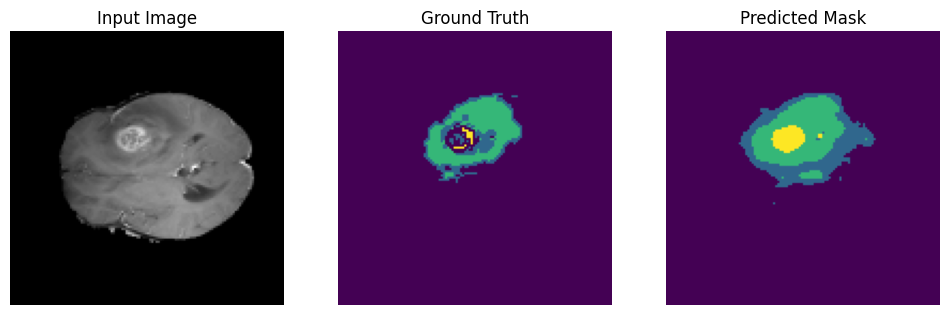

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 368s 131ms/step - accuracy: 0.9422 - loss: 0.2744 - val_accuracy: 0.9424 - val_loss: 0.2913
Epoch 12/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9444 - loss: 0.2644

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


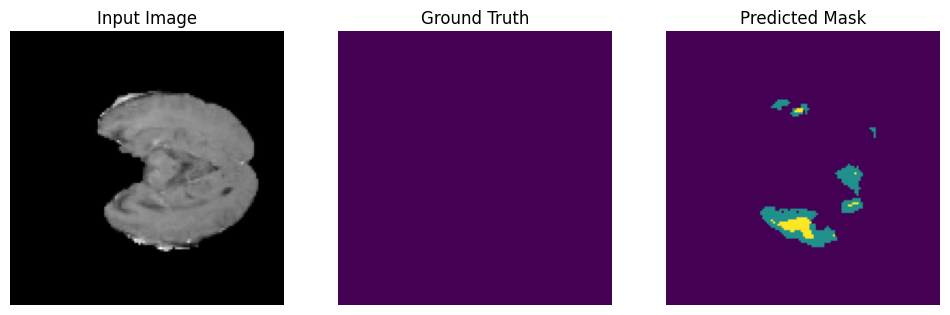

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 403s 147ms/step - accuracy: 0.9444 - loss: 0.2644 - val_accuracy: 0.9433 - val_loss: 0.2890
Epoch 13/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9454 - loss: 0.2630

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


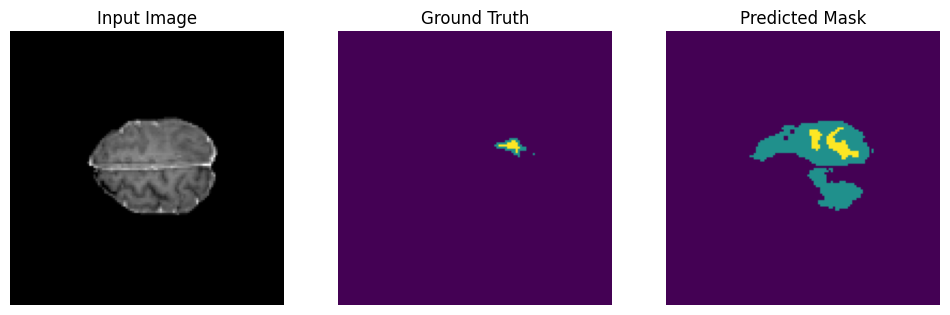

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 402s 147ms/step - accuracy: 0.9454 - loss: 0.2630 - val_accuracy: 0.9436 - val_loss: 0.2881
Epoch 14/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9456 - loss: 0.2632

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


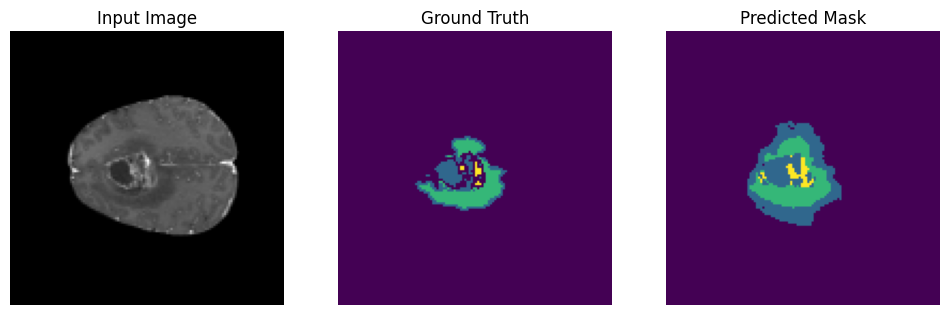

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 391s 143ms/step - accuracy: 0.9456 - loss: 0.2632 - val_accuracy: 0.9439 - val_loss: 0.2868
Epoch 15/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9457 - loss: 0.2576

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


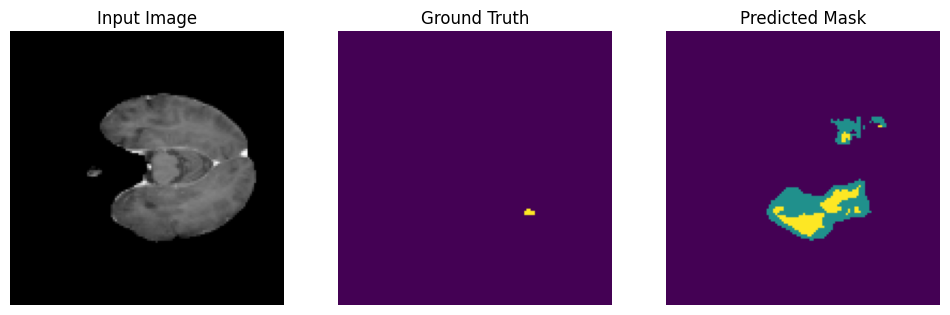

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 373s 136ms/step - accuracy: 0.9457 - loss: 0.2576 - val_accuracy: 0.9457 - val_loss: 0.2864
Epoch 16/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9465 - loss: 0.2572

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


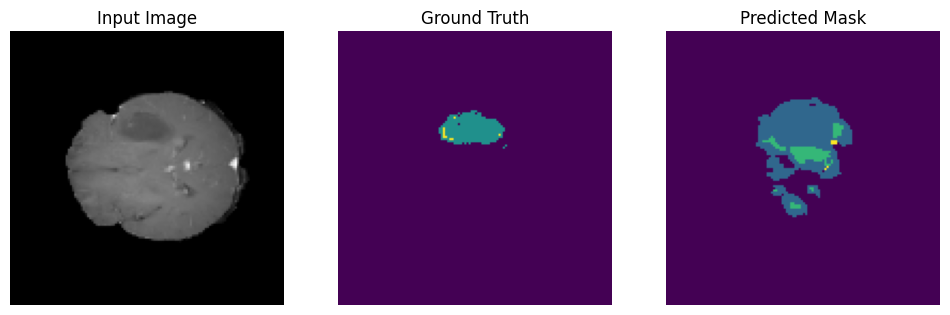

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 369s 135ms/step - accuracy: 0.9465 - loss: 0.2572 - val_accuracy: 0.9442 - val_loss: 0.2853
Epoch 17/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


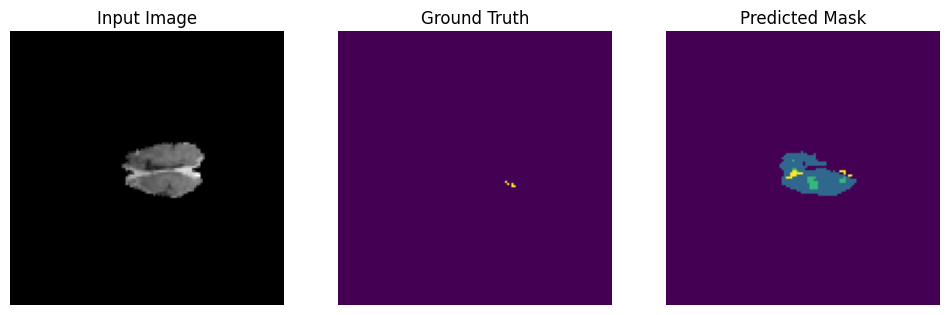

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 369s 135ms/step - accuracy: 0.9461 - loss: 0.2582 - val_accuracy: 0.9466 - val_loss: 0.2856
Epoch 18/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9470 - loss: 0.2540

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


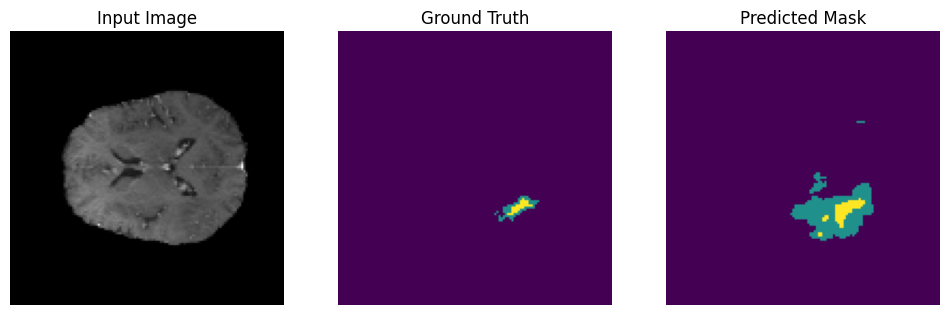

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 369s 135ms/step - accuracy: 0.9470 - loss: 0.2540 - val_accuracy: 0.9454 - val_loss: 0.2847
Epoch 19/35
 590/2740 ━━━━━━━━━━━━━━━━━━━━ 4:37 129ms/step - accuracy: 0.9469 - loss: 0.2543

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# -------------------------
# 1. Paths and Settings
# -------------------------
checkpoint_path = "unet_weighted_div.h5"
initial_epoch = 0

# -------------------------
# 2. Load Data
# -------------------------
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]

# -------------------------
# 3. Custom Weighted Loss (Same as before)
# -------------------------
class_weights_tensor = tf.constant([0.25, 19.03, 34.29, 206.04], dtype=tf.float32)

def weighted_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    weights = tf.reduce_sum(class_weights_tensor * y_true, axis=-1)
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return loss * weights

# -------------------------
# 4. Prediction Callback (Shows Input, Ground Truth, Prediction)
# -------------------------
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.randint(0, len(X_val))
        sample = X_val[idx:idx+1]
        pred = np.argmax(self.model.predict(sample), axis=-1)[0]
        true_mask = np.argmax(Y_val[idx], axis=-1)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(sample[0, :, :, 0], cmap='gray')
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap='viridis')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap='viridis')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# -------------------------
# 5. Load Model if Checkpoint Exists
# -------------------------
if os.path.exists(checkpoint_path):
    print("✅ Found existing checkpoint, loading model...")
    model = load_model(
        checkpoint_path,
        custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss=weighted_categorical_crossentropy,
                  metrics=['accuracy'])
    initial_epoch = 10  # update this to last epoch you trained
else:
    print("❌ No checkpoint found! Cannot fine-tune without base model.")
    raise SystemExit("Train initial model first!")

# -------------------------
# 6. Callbacks
# -------------------------
checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# -------------------------
# 7. Resume Training (Add 25 More Epochs)
# -------------------------
model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    initial_epoch=initial_epoch,
    epochs=initial_epoch + 25,  # continue for 25 more epochs
    batch_size=8,
    callbacks=[checkpoint, early_stop, PredictionCallback()]
)

✅ Found existing checkpoint, loading model...


Epoch 19/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9468 - loss: 0.2542

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step


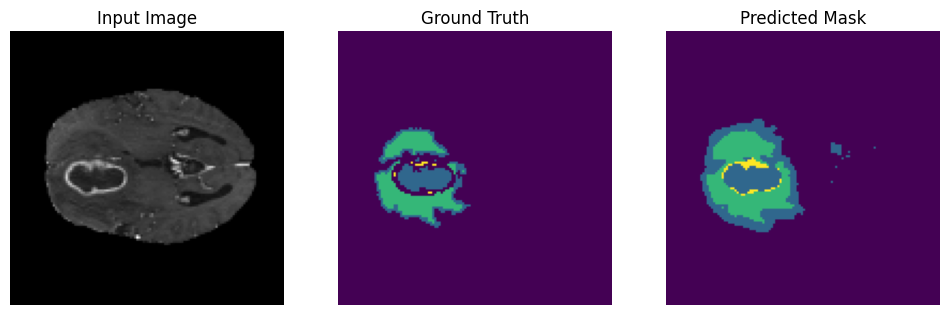

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 349s 125ms/step - accuracy: 0.9468 - loss: 0.2542 - val_accuracy: 0.9452 - val_loss: 0.2839
Epoch 20/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9474 - loss: 0.2534

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


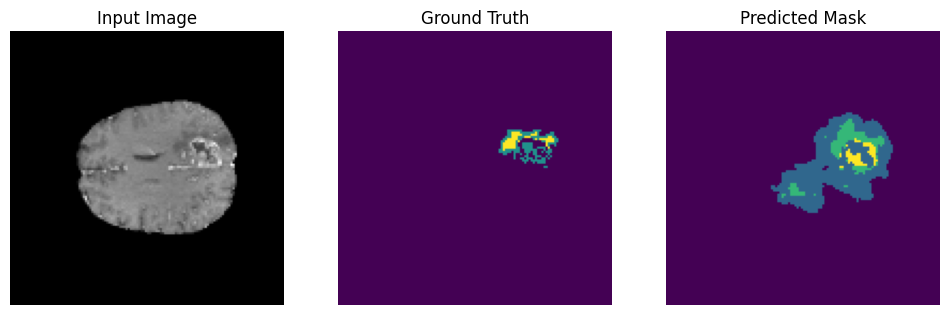

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 343s 125ms/step - accuracy: 0.9474 - loss: 0.2534 - val_accuracy: 0.9445 - val_loss: 0.2832
Epoch 21/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


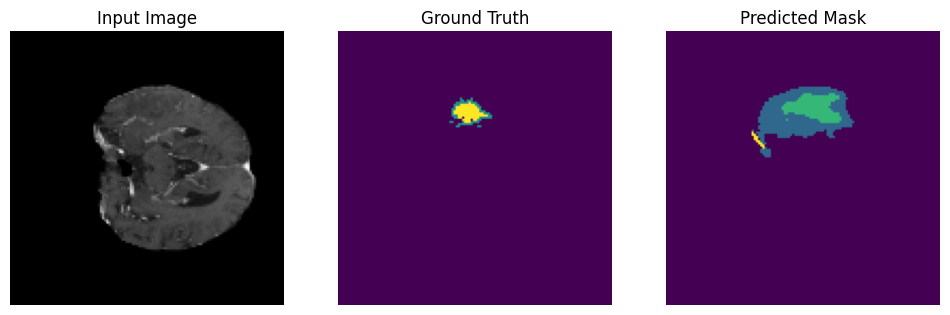

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 337s 123ms/step - accuracy: 0.9468 - loss: 0.2534 - val_accuracy: 0.9461 - val_loss: 0.2837
Epoch 22/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9476 - loss: 0.2519

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


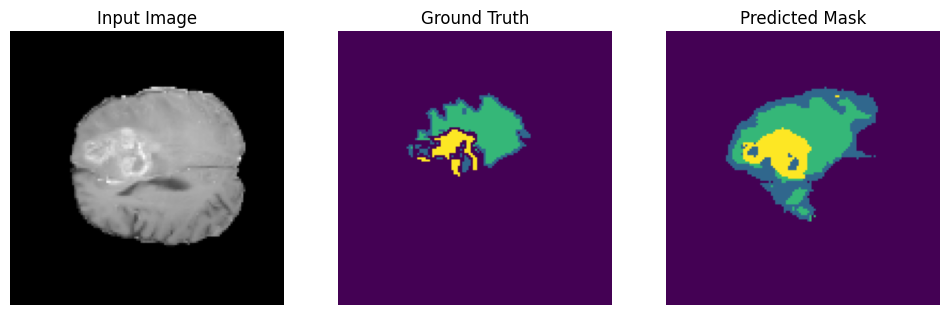

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 344s 126ms/step - accuracy: 0.9476 - loss: 0.2519 - val_accuracy: 0.9464 - val_loss: 0.2830
Epoch 23/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


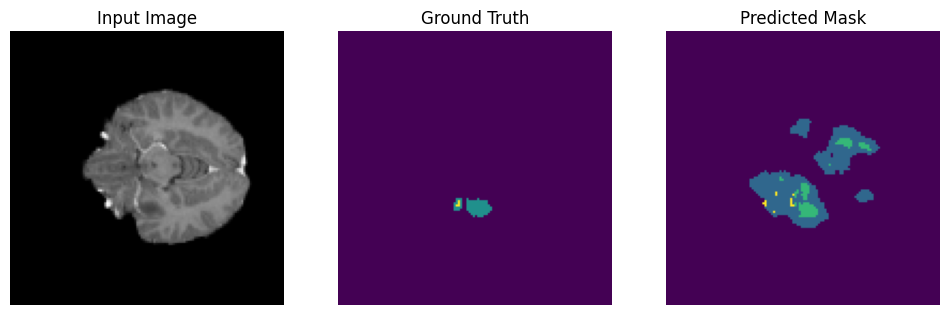

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 340s 124ms/step - accuracy: 0.9477 - loss: 0.2496 - val_accuracy: 0.9465 - val_loss: 0.2834
Epoch 24/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9473 - loss: 0.2524

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


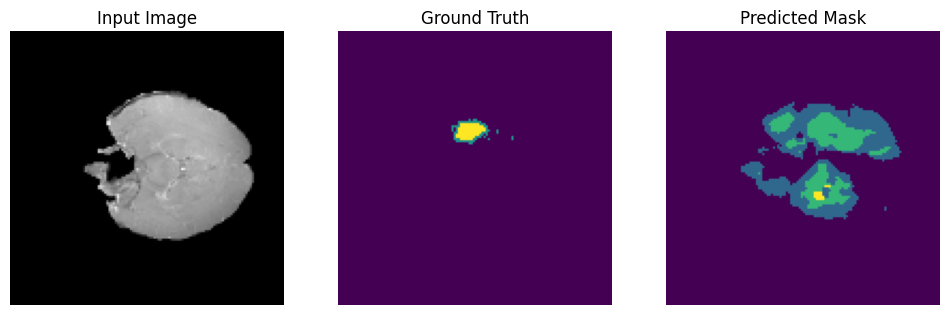

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 355s 129ms/step - accuracy: 0.9473 - loss: 0.2524 - val_accuracy: 0.9466 - val_loss: 0.2826
Epoch 25/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


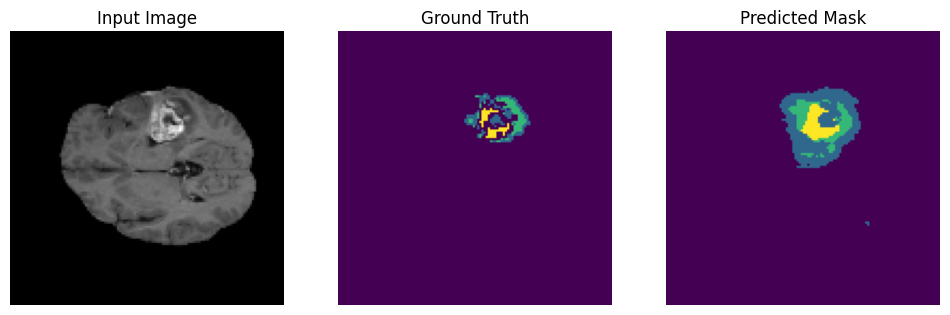

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 356s 130ms/step - accuracy: 0.9479 - loss: 0.2492 - val_accuracy: 0.9474 - val_loss: 0.2828
Epoch 26/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9478 - loss: 0.2485

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


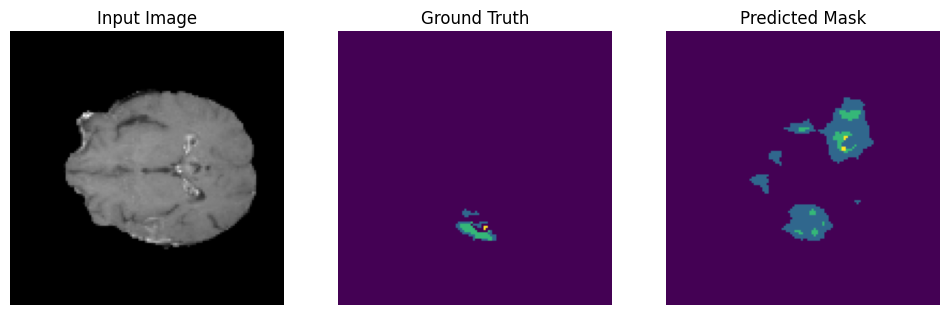

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 374s 136ms/step - accuracy: 0.9478 - loss: 0.2485 - val_accuracy: 0.9455 - val_loss: 0.2821
Epoch 27/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9477 - loss: 0.2478

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


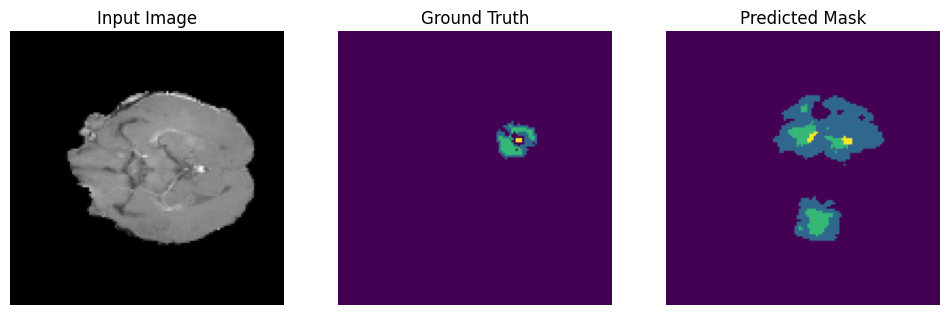

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 352s 128ms/step - accuracy: 0.9477 - loss: 0.2478 - val_accuracy: 0.9465 - val_loss: 0.2820
Epoch 28/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9485 - loss: 0.2462

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


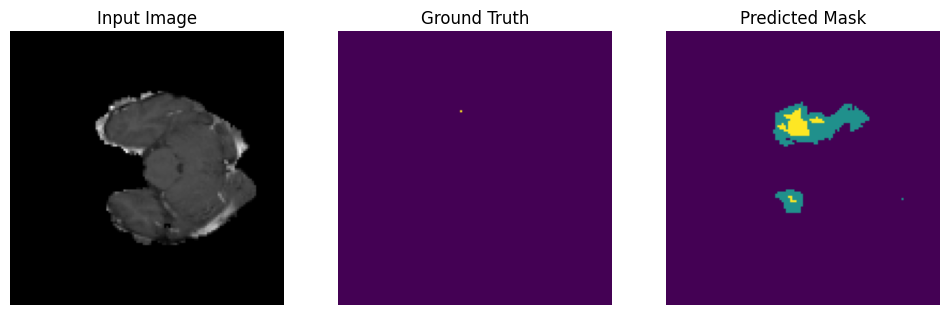

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 346s 126ms/step - accuracy: 0.9485 - loss: 0.2462 - val_accuracy: 0.9469 - val_loss: 0.2819
Epoch 29/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9484 - loss: 0.2481

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


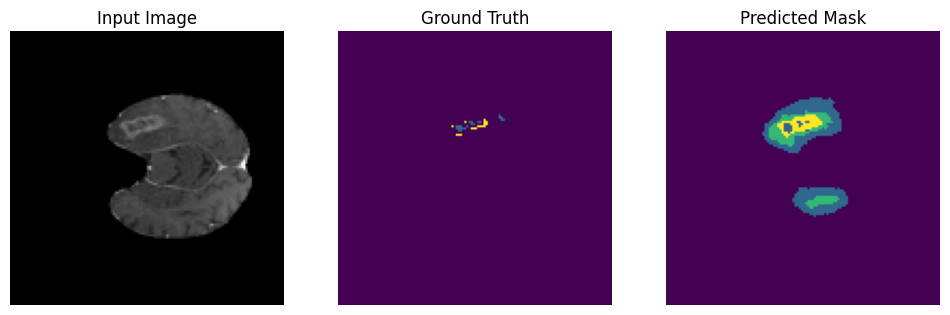

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 364s 133ms/step - accuracy: 0.9484 - loss: 0.2481 - val_accuracy: 0.9474 - val_loss: 0.2818
Epoch 30/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9490 - loss: 0.2455

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


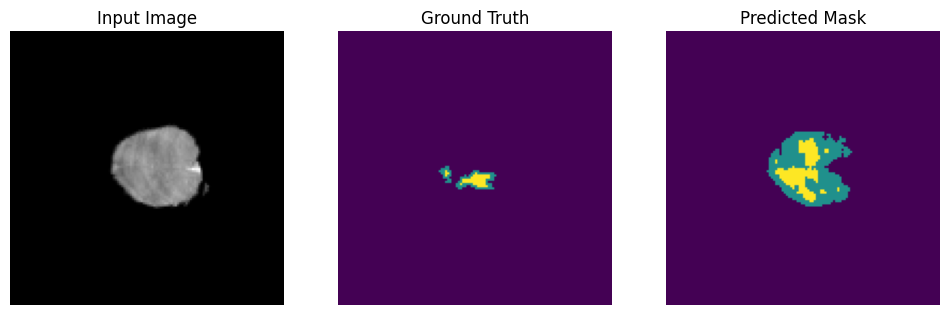

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 349s 127ms/step - accuracy: 0.9490 - loss: 0.2455 - val_accuracy: 0.9467 - val_loss: 0.2814
Epoch 31/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


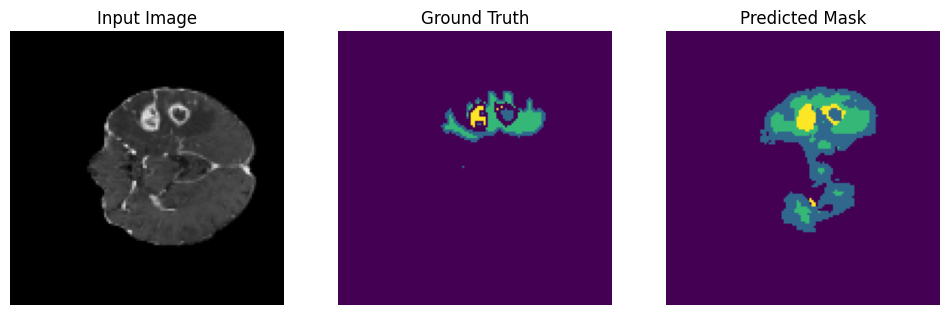

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 335s 122ms/step - accuracy: 0.9484 - loss: 0.2448 - val_accuracy: 0.9475 - val_loss: 0.2815
Epoch 32/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


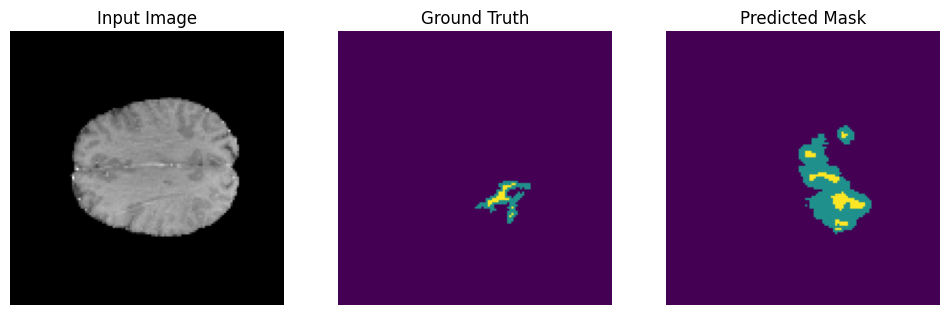

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 336s 123ms/step - accuracy: 0.9487 - loss: 0.2455 - val_accuracy: 0.9466 - val_loss: 0.2816
Epoch 33/35
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9486 - loss: 0.2444

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


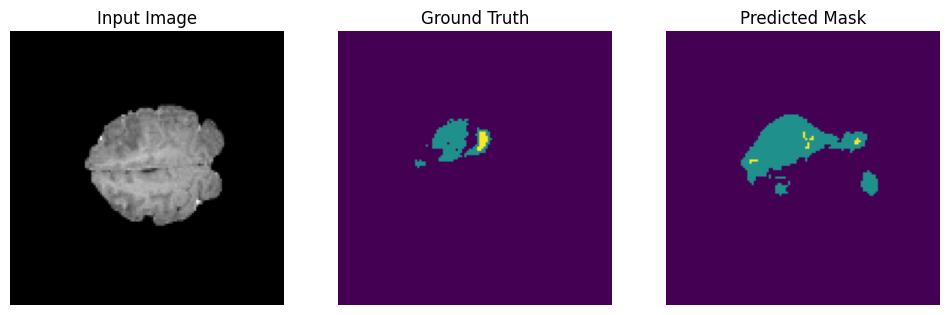

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 339s 124ms/step - accuracy: 0.9486 - loss: 0.2444 - val_accuracy: 0.9464 - val_loss: 0.2808
Epoch 34/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


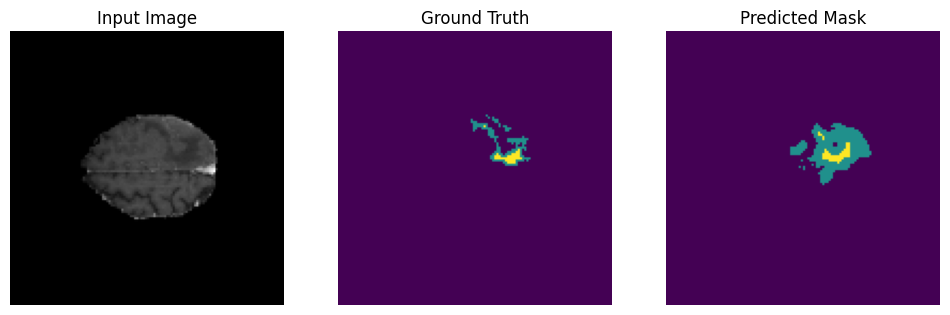

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 338s 123ms/step - accuracy: 0.9489 - loss: 0.2440 - val_accuracy: 0.9478 - val_loss: 0.2817
Epoch 35/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


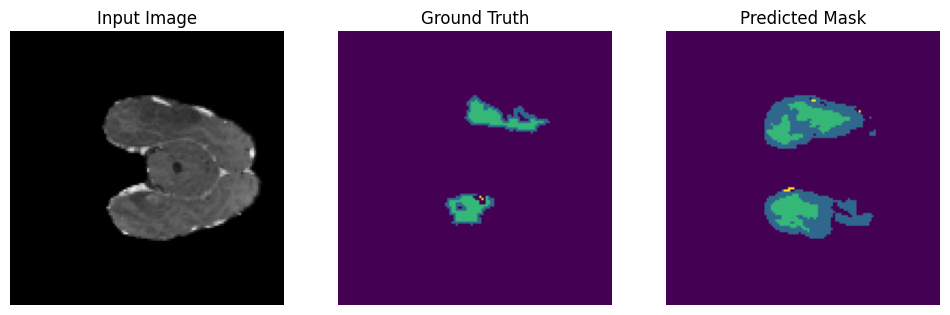

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 340s 124ms/step - accuracy: 0.9489 - loss: 0.2437 - val_accuracy: 0.9478 - val_loss: 0.2811


In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# -------------------------
# 1. Paths and Settings
# -------------------------
checkpoint_path = "unet_weighted_div.h5"
initial_epoch = 0

# -------------------------
# 2. Load Data
# -------------------------
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]

# -------------------------
# 3. Custom Weighted Loss (Same as before)
# -------------------------
class_weights_tensor = tf.constant([0.25, 19.03, 34.29, 206.04], dtype=tf.float32)

def weighted_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    weights = tf.reduce_sum(class_weights_tensor * y_true, axis=-1)
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return loss * weights

# -------------------------
# 4. Prediction Callback (Shows Input, Ground Truth, Prediction)
# -------------------------
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.randint(0, len(X_val))
        sample = X_val[idx:idx+1]
        pred = np.argmax(self.model.predict(sample), axis=-1)[0]
        true_mask = np.argmax(Y_val[idx], axis=-1)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(sample[0, :, :, 0], cmap='gray')
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap='viridis')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap='viridis')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# -------------------------
# 5. Load Model if Checkpoint Exists
# -------------------------
if os.path.exists(checkpoint_path):
    print("✅ Found existing checkpoint, loading model...")
    model = load_model(
        checkpoint_path,
        custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss=weighted_categorical_crossentropy,
                  metrics=['accuracy'])
    initial_epoch = 18  # update this to last epoch you trained
else:
    print("❌ No checkpoint found! Cannot fine-tune without base model.")
    raise SystemExit("Train initial model first!")

# -------------------------
# 6. Callbacks
# -------------------------
checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# -------------------------
# 7. Resume Training (Add 25 More Epochs)
# -------------------------
model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    initial_epoch=initial_epoch,
    epochs=initial_epoch + 17,  # continue for 25 more epochs
    batch_size=8,
    callbacks=[checkpoint, early_stop, PredictionCallback()]
)

✅ Found existing checkpoint, loading model...
Epoch 36/50
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9489 - loss: 0.2439

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


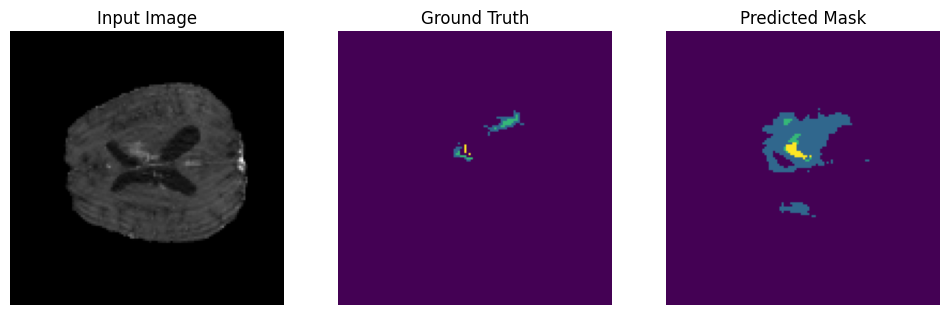

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 352s 126ms/step - accuracy: 0.9489 - loss: 0.2439 - val_accuracy: 0.9475 - val_loss: 0.2813
Epoch 37/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


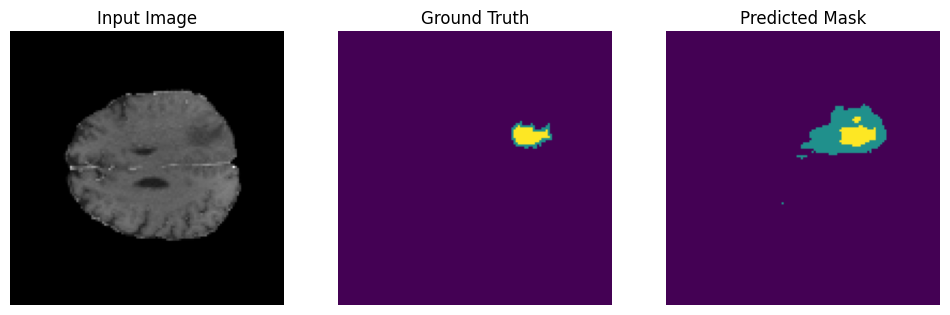

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 343s 125ms/step - accuracy: 0.9492 - loss: 0.2449 - val_accuracy: 0.9481 - val_loss: 0.2817
Epoch 38/50
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9494 - loss: 0.2419

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


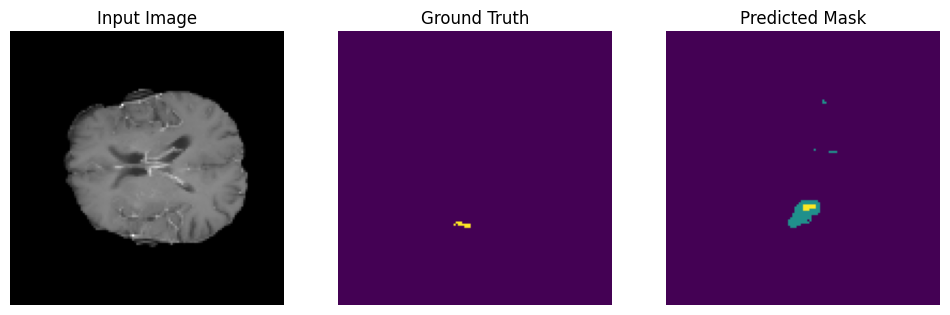

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 341s 125ms/step - accuracy: 0.9494 - loss: 0.2419 - val_accuracy: 0.9483 - val_loss: 0.2810
Epoch 39/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


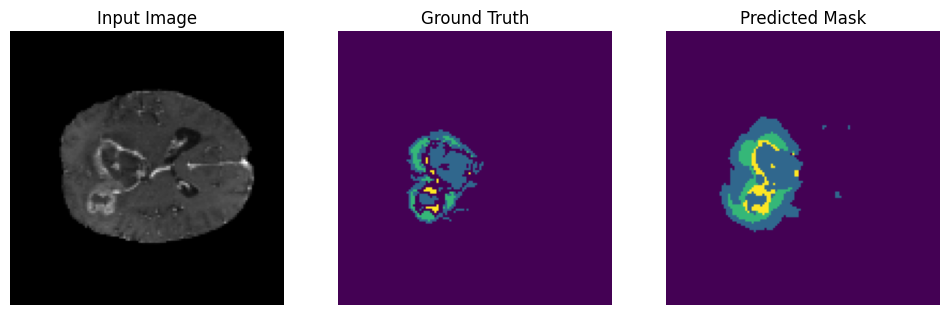

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 339s 124ms/step - accuracy: 0.9494 - loss: 0.2432 - val_accuracy: 0.9479 - val_loss: 0.2812
Epoch 40/50
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9491 - loss: 0.2422

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


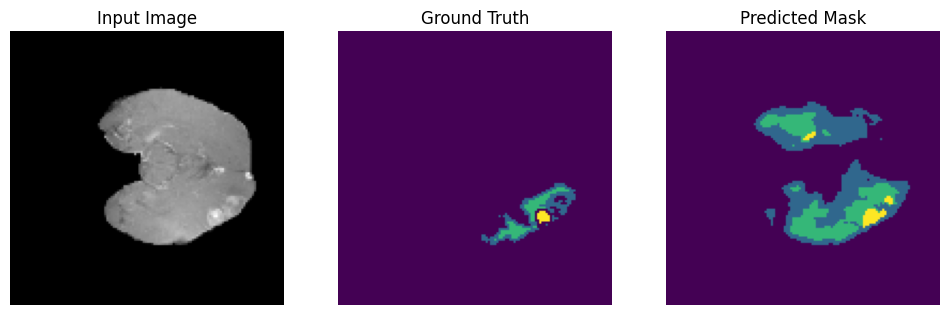

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 346s 126ms/step - accuracy: 0.9491 - loss: 0.2422 - val_accuracy: 0.9478 - val_loss: 0.2809
Epoch 41/50
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9495 - loss: 0.2437

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


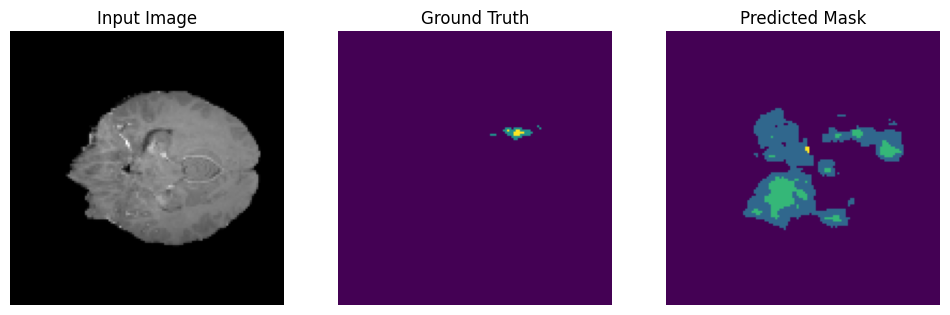

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 344s 125ms/step - accuracy: 0.9495 - loss: 0.2437 - val_accuracy: 0.9474 - val_loss: 0.2805
Epoch 42/50
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9492 - loss: 0.2430

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


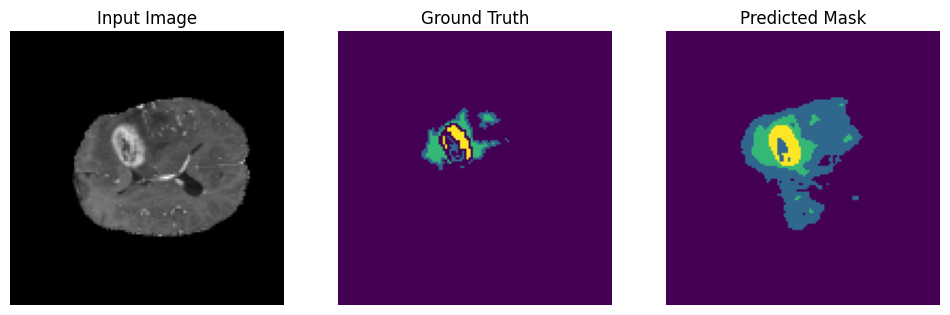

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 342s 125ms/step - accuracy: 0.9492 - loss: 0.2430 - val_accuracy: 0.9478 - val_loss: 0.2805
Epoch 43/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


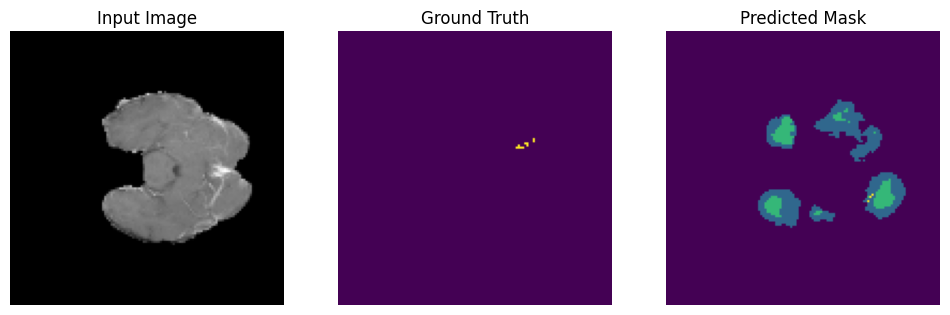

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 342s 125ms/step - accuracy: 0.9498 - loss: 0.2405 - val_accuracy: 0.9495 - val_loss: 0.2810
Epoch 44/50
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9497 - loss: 0.2415

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


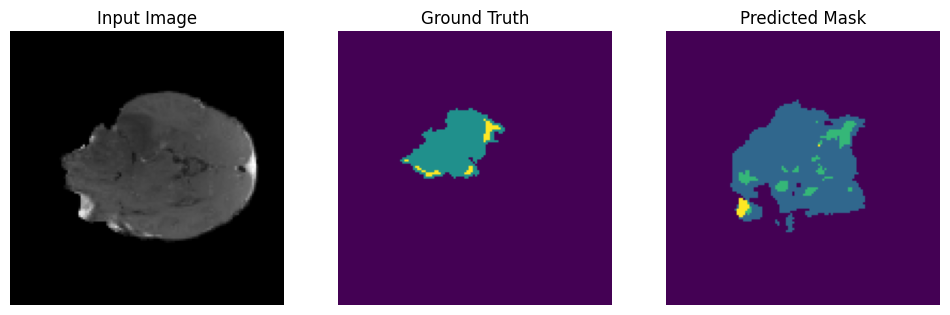

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 345s 126ms/step - accuracy: 0.9497 - loss: 0.2415 - val_accuracy: 0.9471 - val_loss: 0.2802
Epoch 45/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


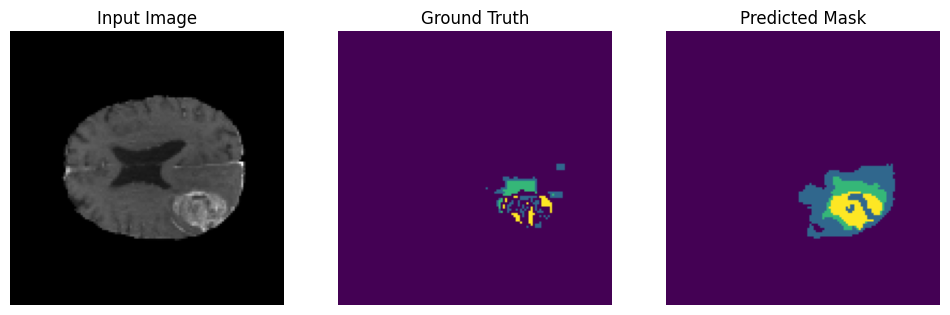

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 345s 126ms/step - accuracy: 0.9498 - loss: 0.2402 - val_accuracy: 0.9483 - val_loss: 0.2808
Epoch 46/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


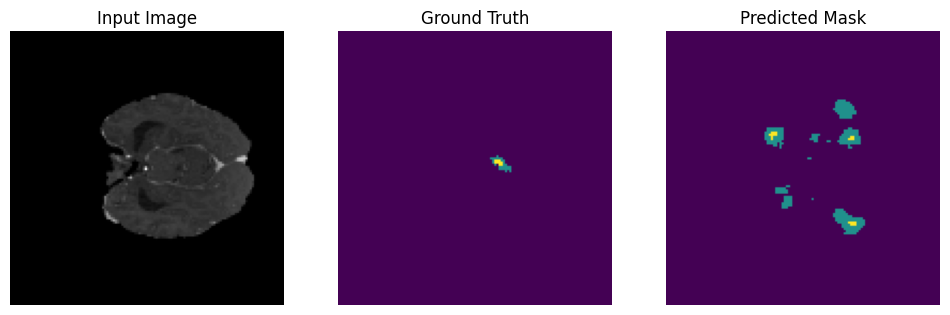

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 346s 126ms/step - accuracy: 0.9499 - loss: 0.2397 - val_accuracy: 0.9476 - val_loss: 0.2803
Epoch 47/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


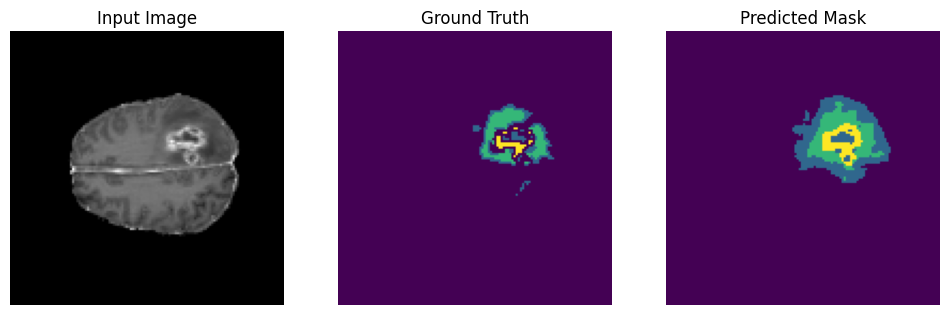

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 349s 127ms/step - accuracy: 0.9499 - loss: 0.2413 - val_accuracy: 0.9497 - val_loss: 0.2809
Epoch 48/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


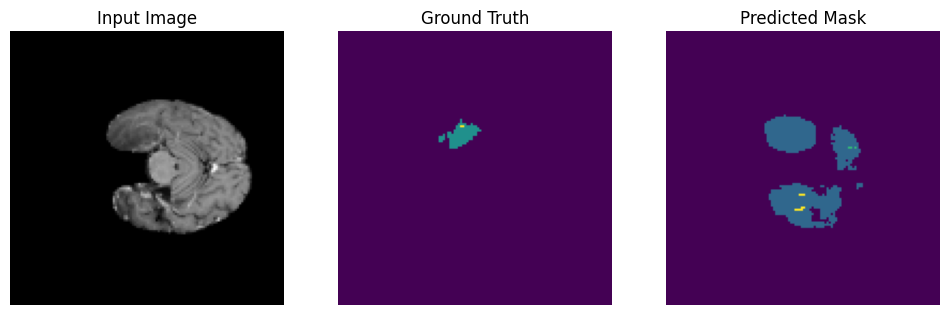

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 343s 125ms/step - accuracy: 0.9502 - loss: 0.2392 - val_accuracy: 0.9485 - val_loss: 0.2805
Epoch 49/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


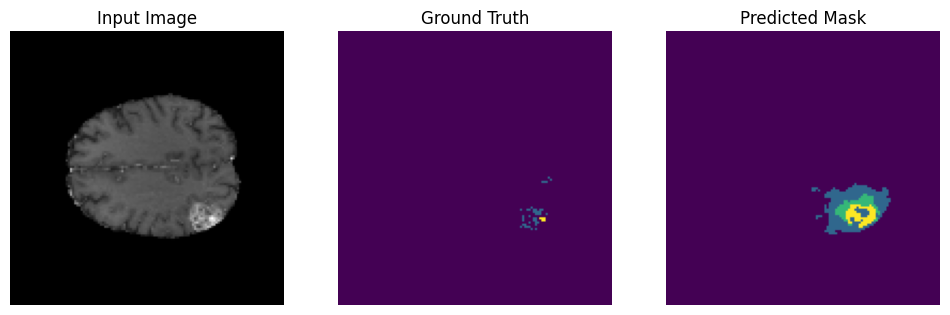

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 352s 128ms/step - accuracy: 0.9503 - loss: 0.2376 - val_accuracy: 0.9487 - val_loss: 0.2804


In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# -------------------------
# 1. Paths and Settings
# -------------------------
checkpoint_path = "unet_weighted_div.h5"
initial_epoch = 0

# -------------------------
# 2. Load Data
# -------------------------
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]

# -------------------------
# 3. Custom Weighted Loss (Same as before)
# -------------------------
class_weights_tensor = tf.constant([0.25, 19.03, 34.29, 206.04], dtype=tf.float32)

def weighted_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    weights = tf.reduce_sum(class_weights_tensor * y_true, axis=-1)
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return loss * weights

# -------------------------
# 4. Prediction Callback (Shows Input, Ground Truth, Prediction)
# -------------------------
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.randint(0, len(X_val))
        sample = X_val[idx:idx+1]
        pred = np.argmax(self.model.predict(sample), axis=-1)[0]
        true_mask = np.argmax(Y_val[idx], axis=-1)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(sample[0, :, :, 0], cmap='gray')
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap='viridis')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap='viridis')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# -------------------------
# 5. Load Model if Checkpoint Exists
# -------------------------
if os.path.exists(checkpoint_path):
    print("✅ Found existing checkpoint, loading model...")
    model = load_model(
        checkpoint_path,
        custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss=weighted_categorical_crossentropy,
                  metrics=['accuracy'])
    initial_epoch = 35 # update this to last epoch you trained
else:
    print("❌ No checkpoint found! Cannot fine-tune without base model.")
    raise SystemExit("Train initial model first!")

# -------------------------
# 6. Callbacks
# -------------------------
checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# -------------------------
# 7. Resume Training (Add 25 More Epochs)
# -------------------------
model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    initial_epoch=initial_epoch,
    epochs=initial_epoch + 15,  # continue for 25 more epochs
    batch_size=8,
    callbacks=[checkpoint, early_stop, PredictionCallback()]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


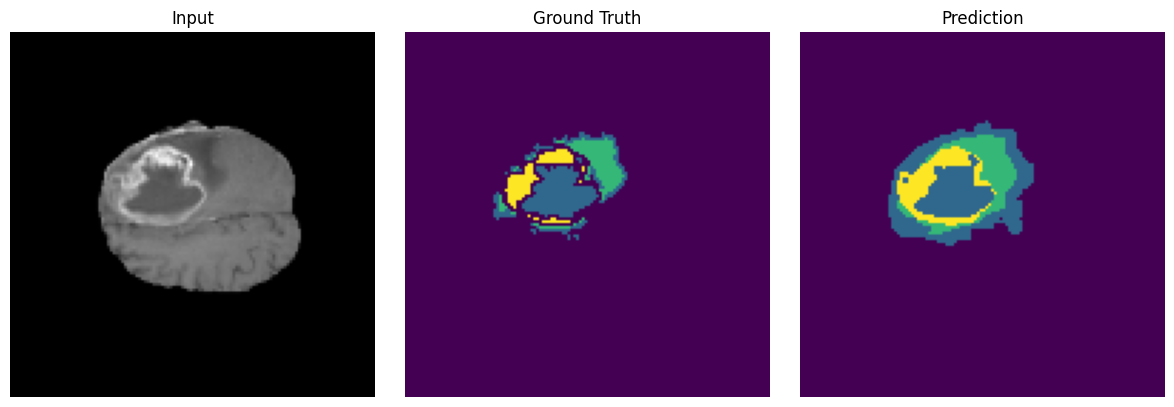

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


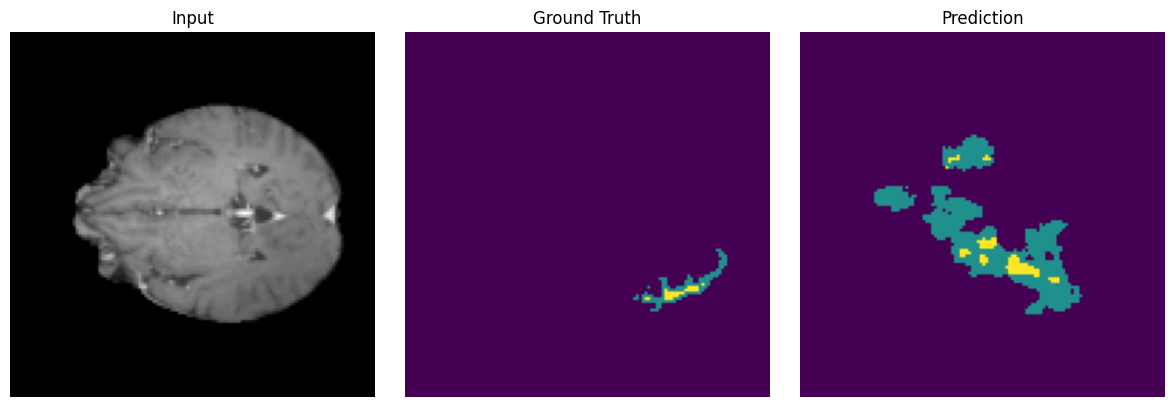

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


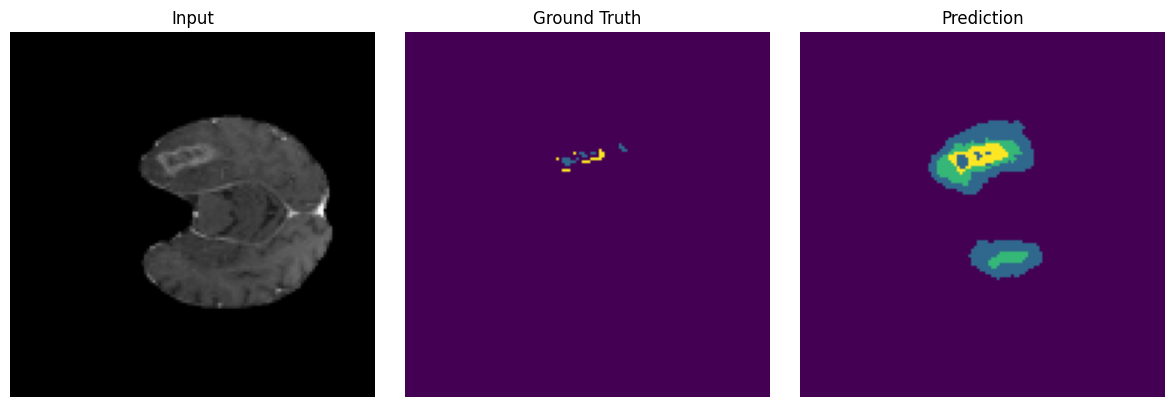

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


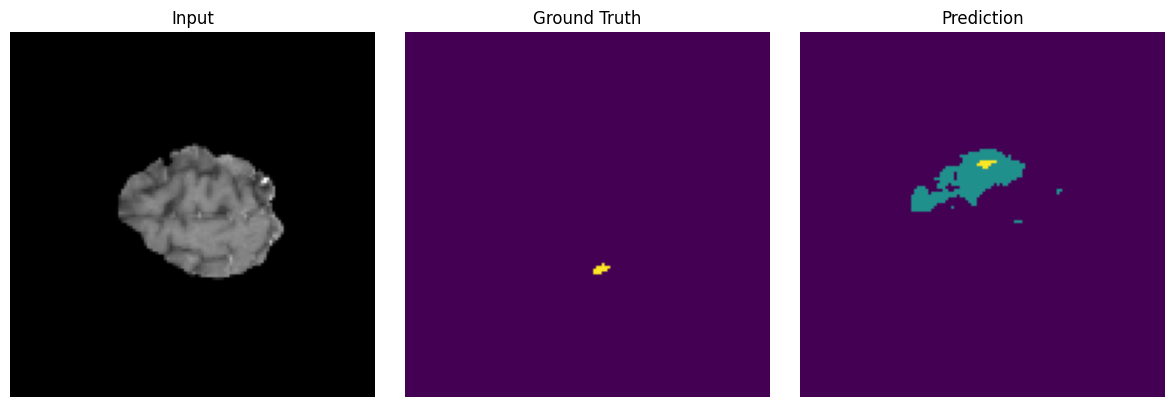

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


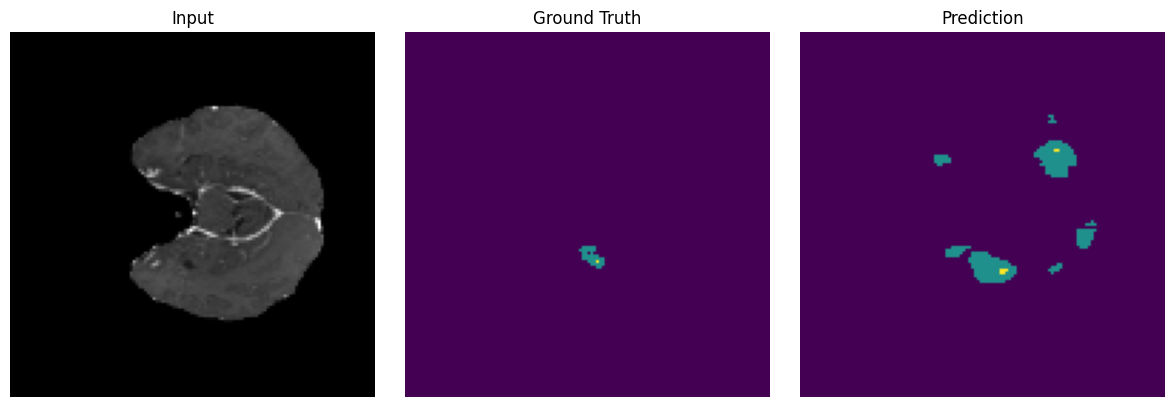

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


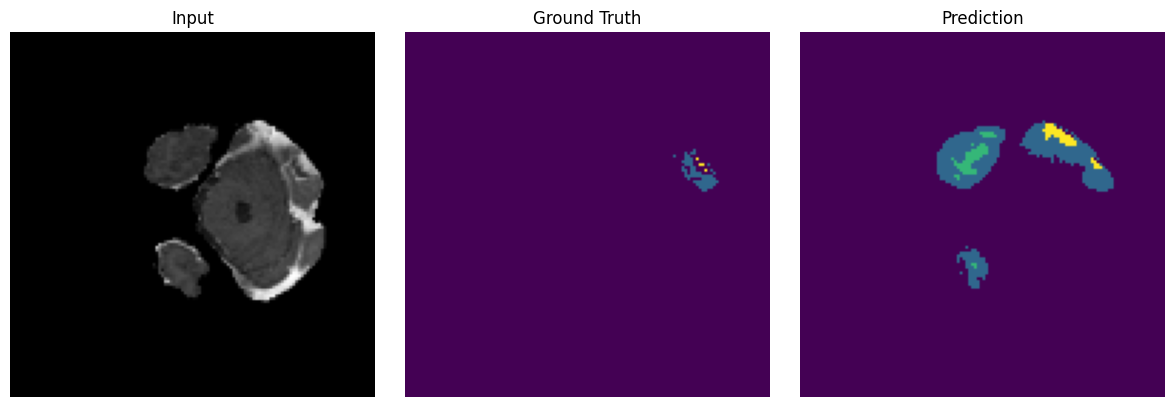

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


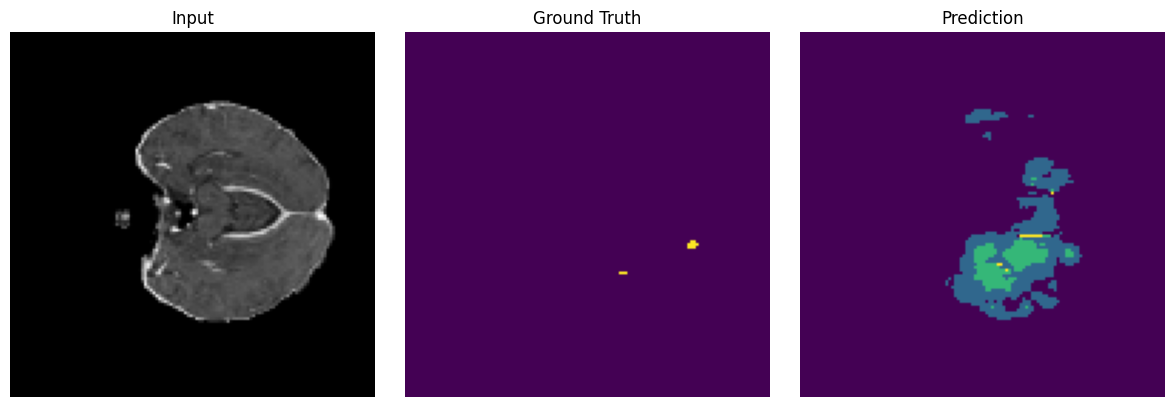

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


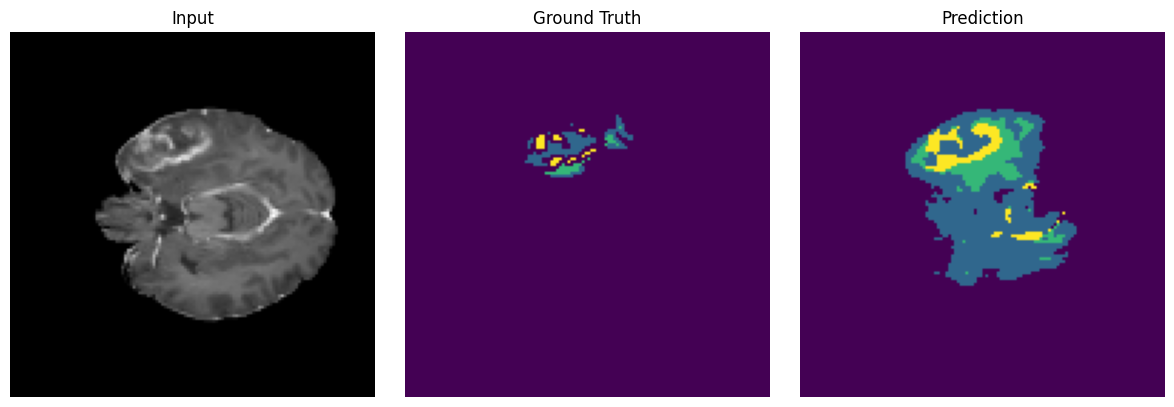

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


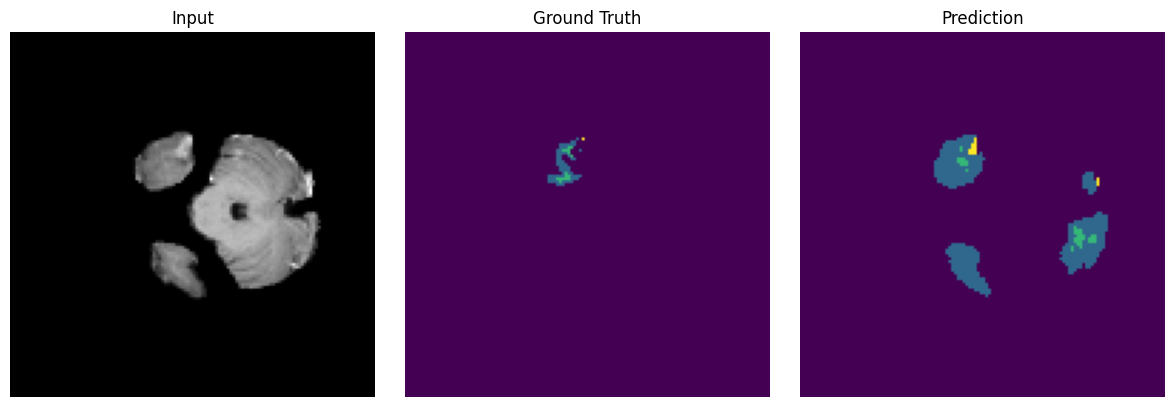

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


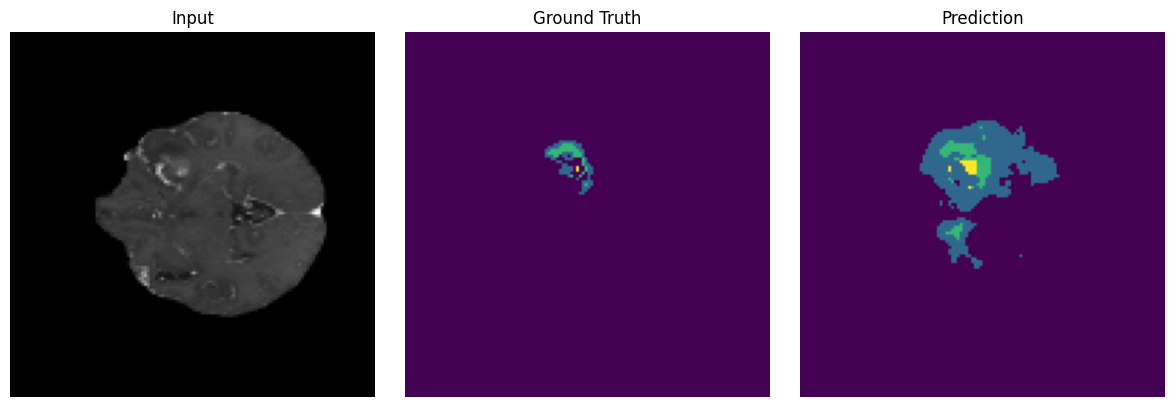

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


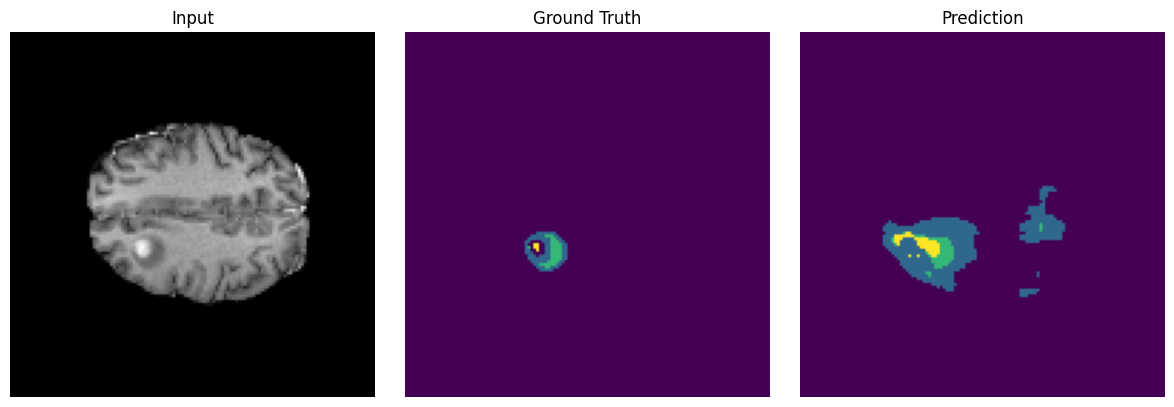

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


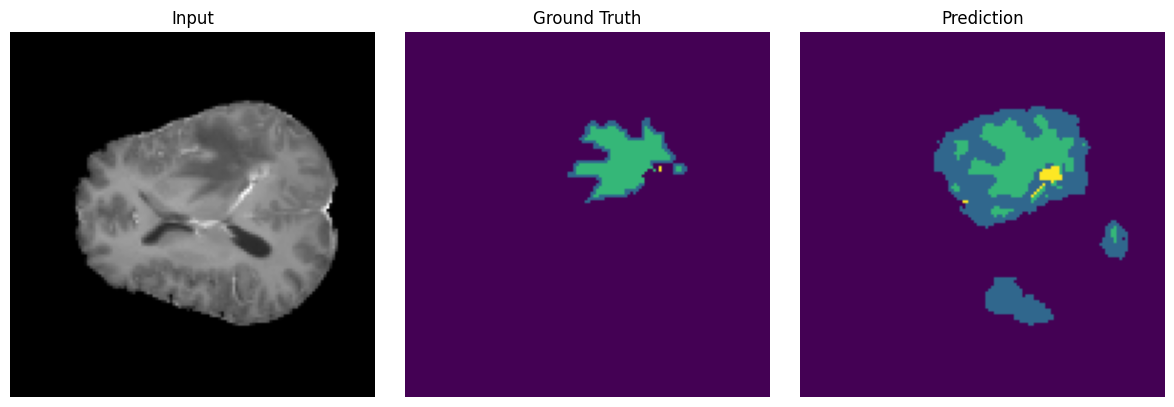

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


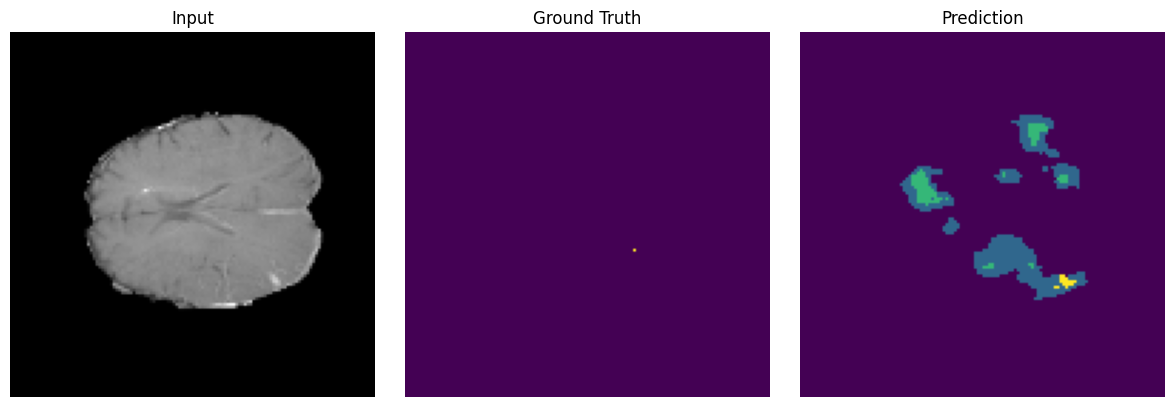

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


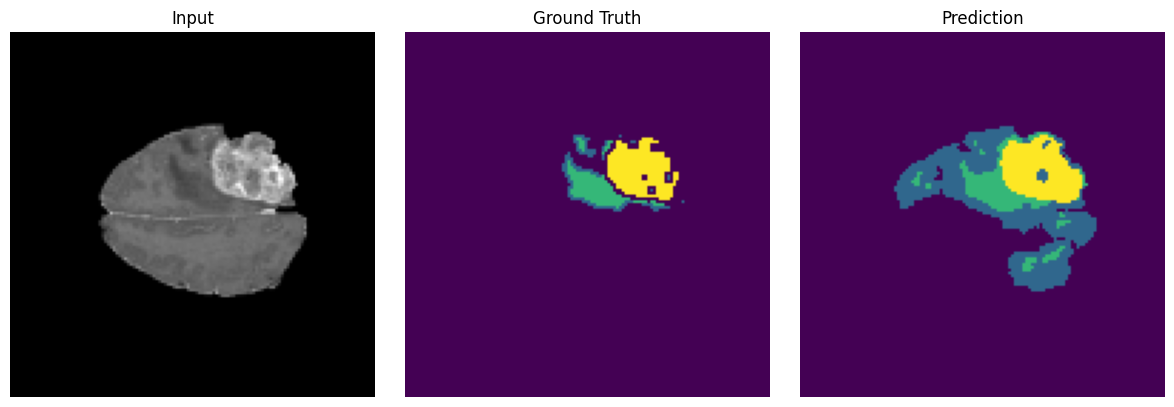

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


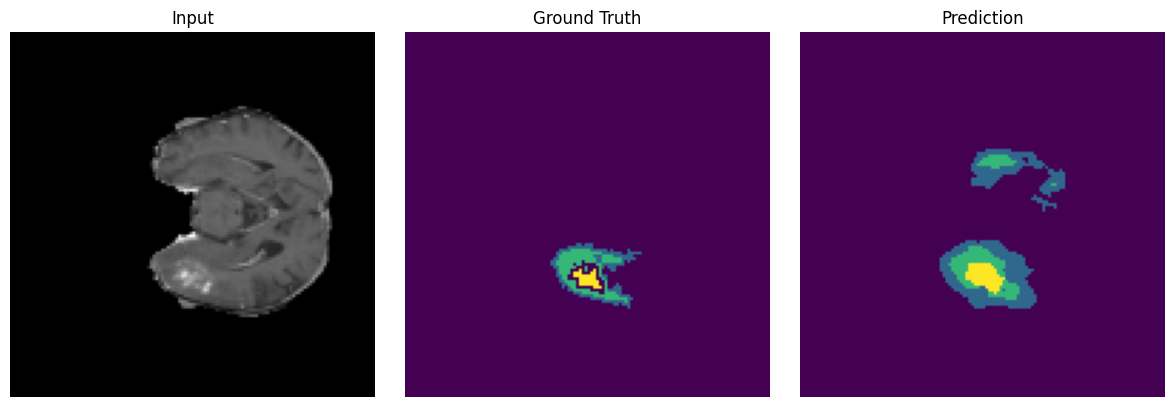

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


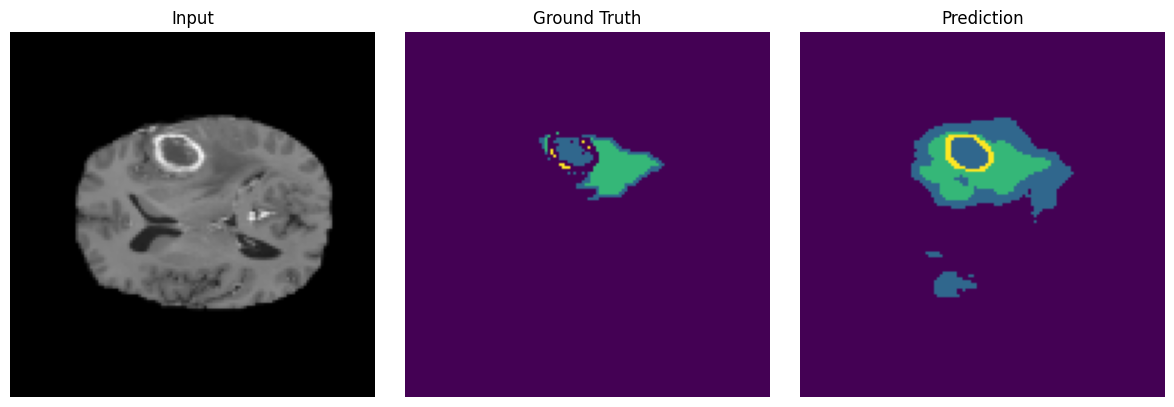

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


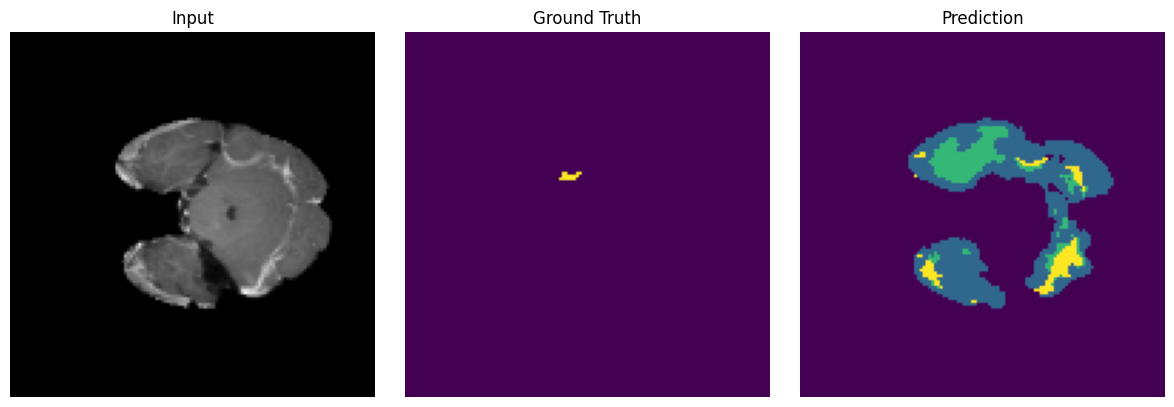

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


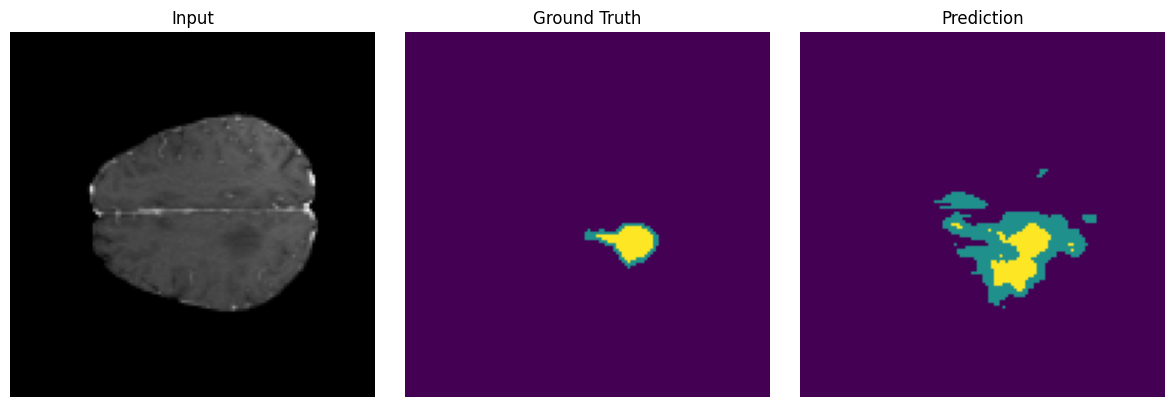

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


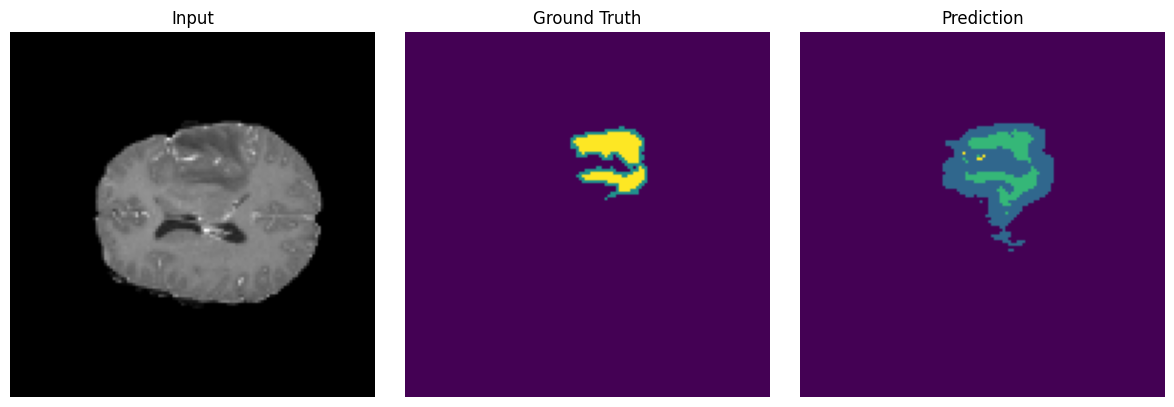

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


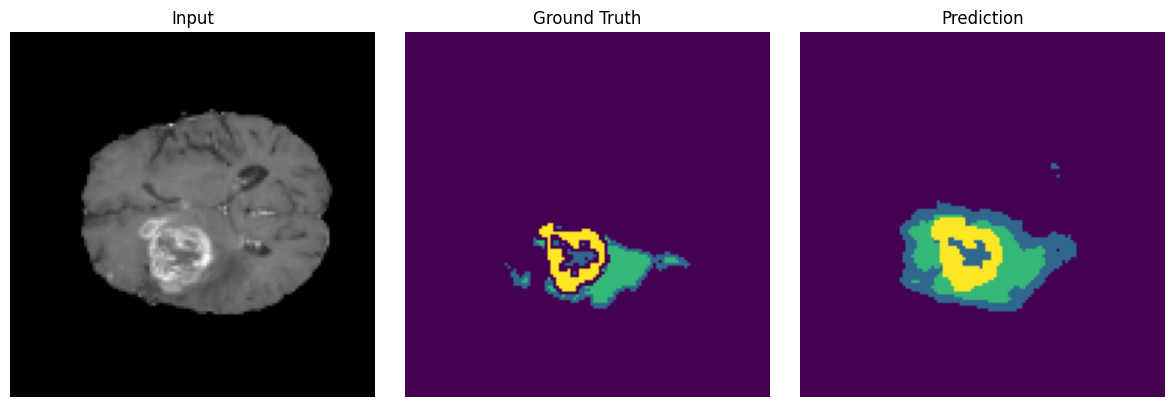

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


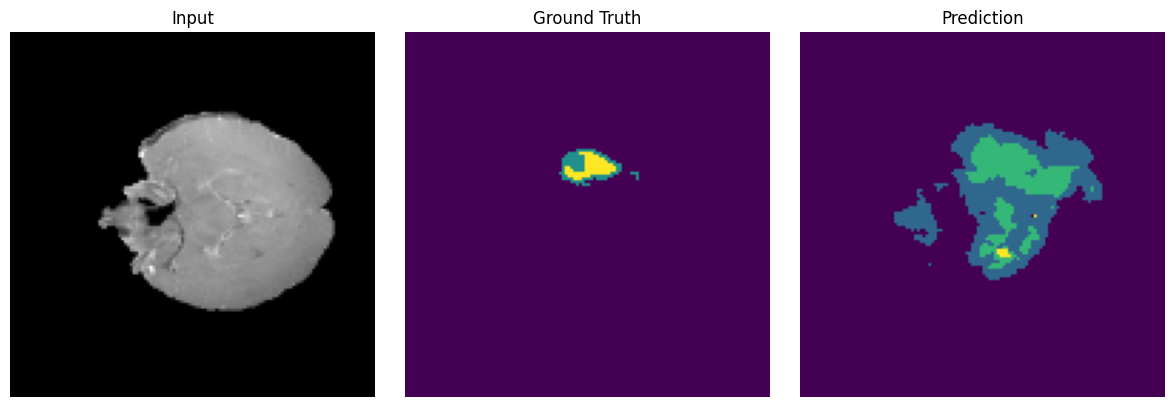

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


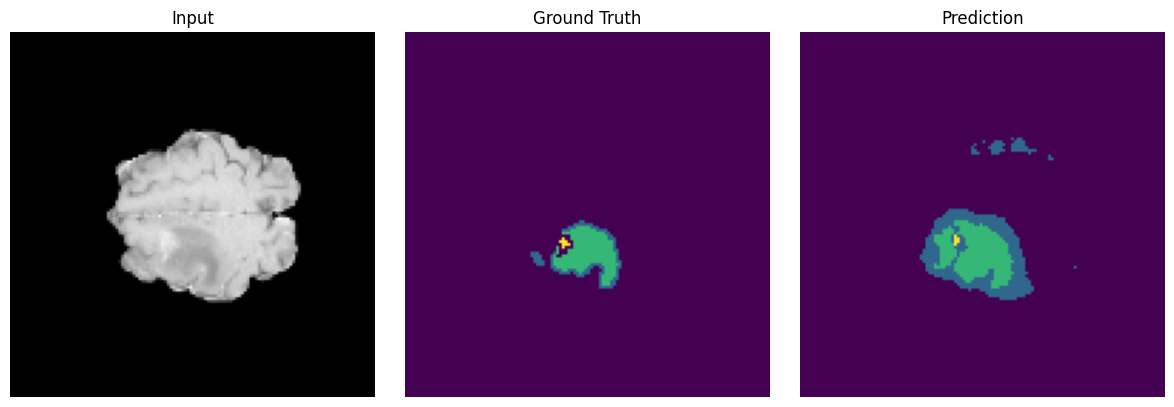

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


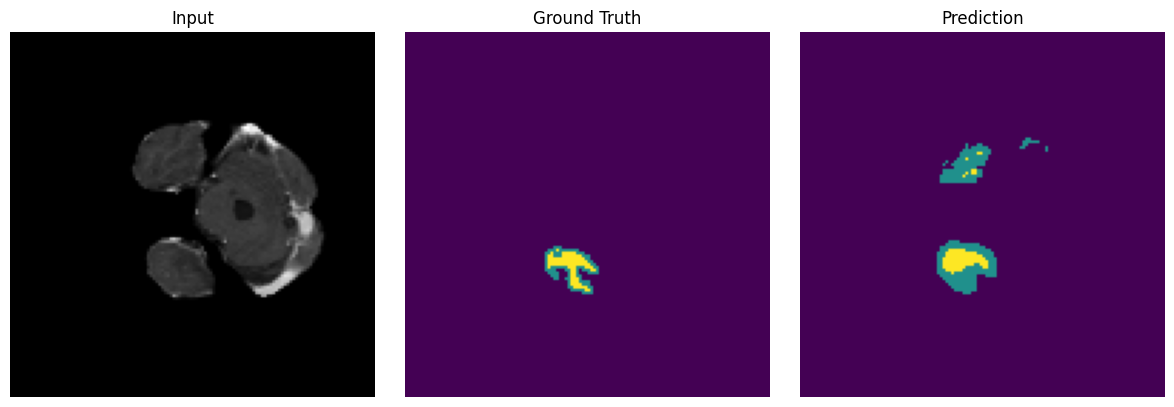

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


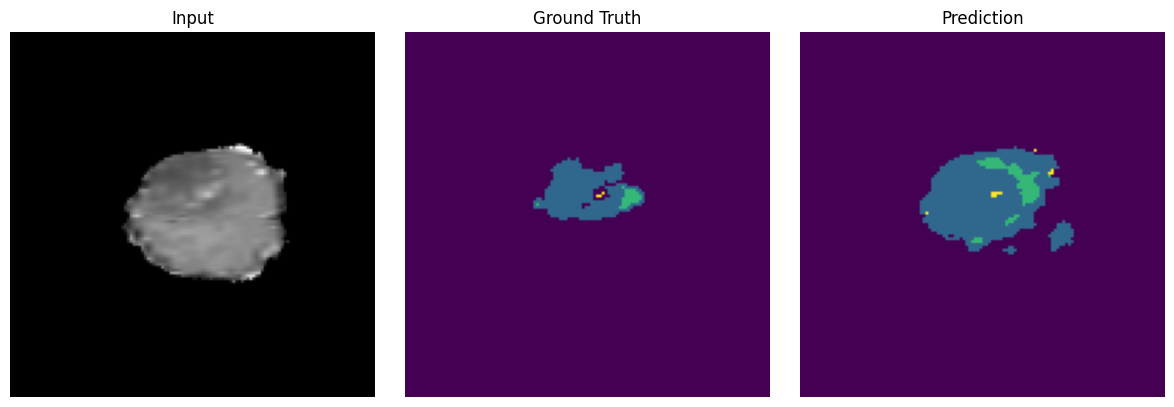

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


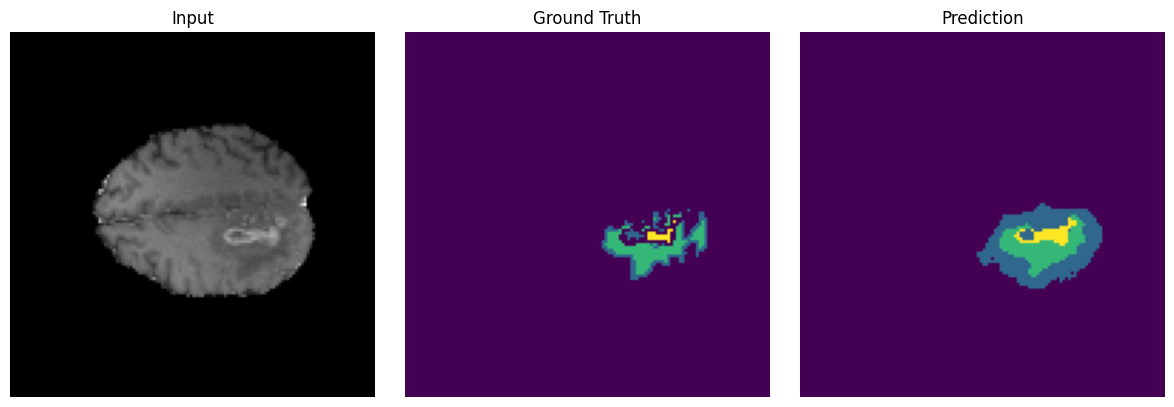

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


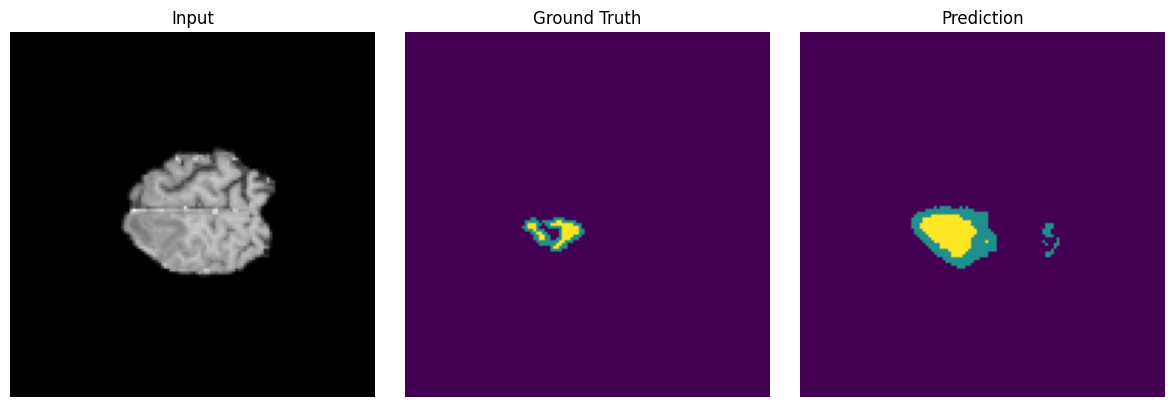

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


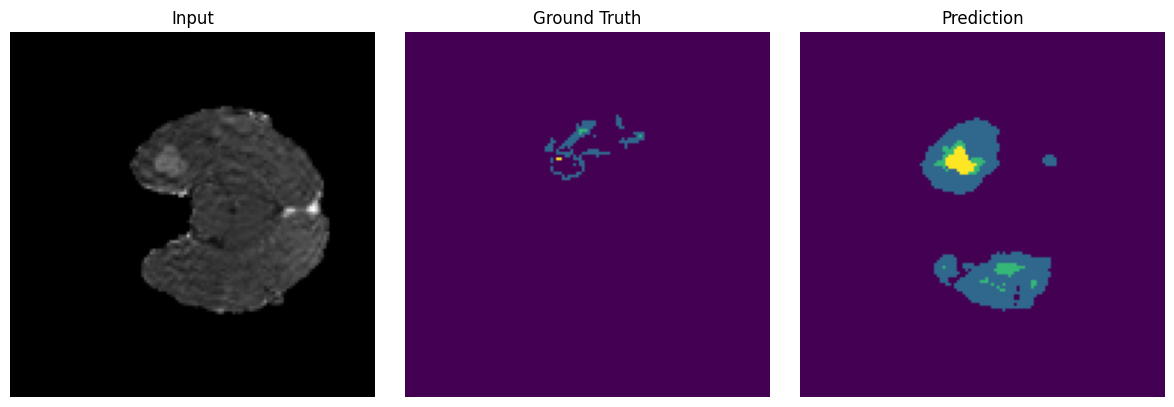

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


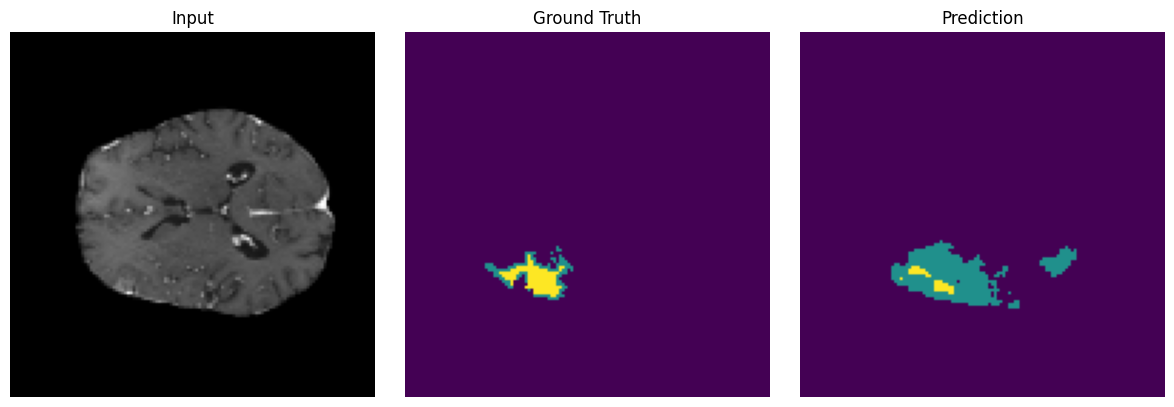

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


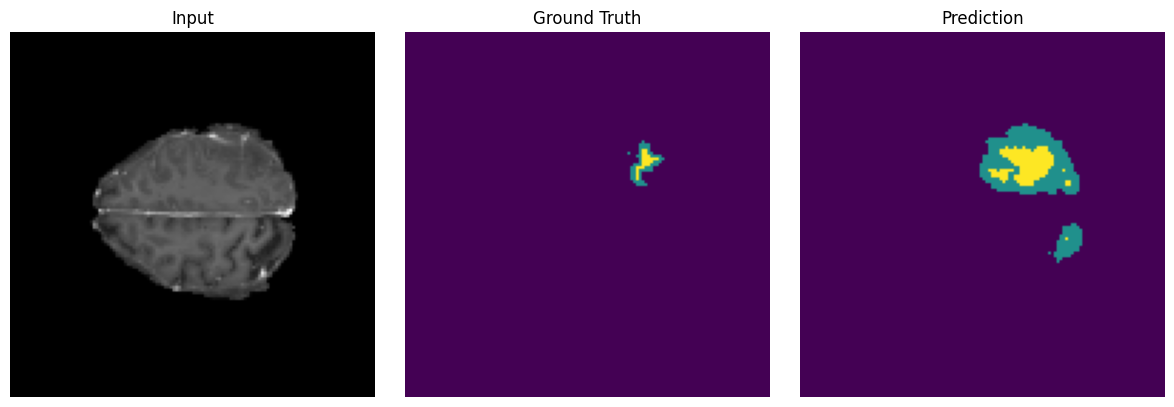

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


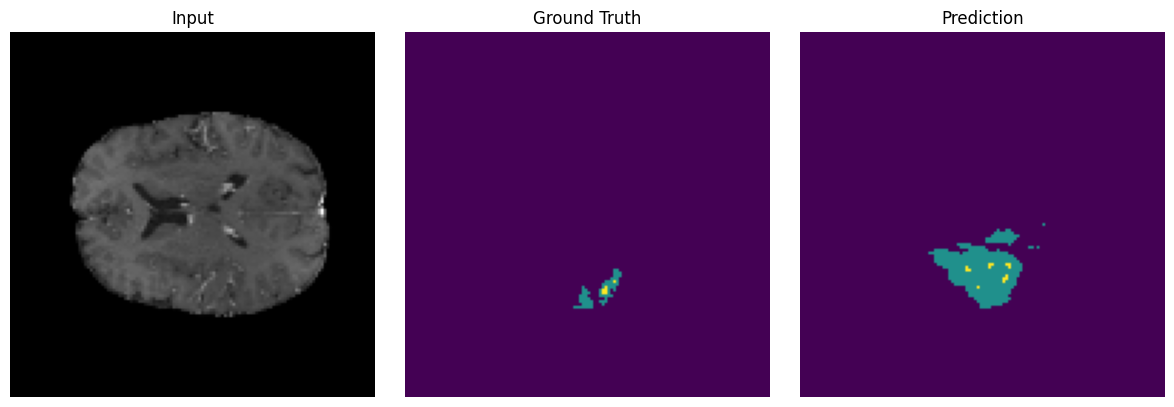

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model with custom loss
model = load_model(
    "unet_weighted_div.h5",
    custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
)

# Test on 30 random samples
num_samples = 30
indices = np.random.choice(len(X_val), num_samples, replace=False)

for i, idx in enumerate(indices):
    sample = X_val[idx:idx+1]  # shape (1, 128, 128, 1)
    true_mask = np.argmax(Y_val[idx], axis=-1)  # shape (128, 128)
    pred = model.predict(sample)
    pred_mask = np.argmax(pred[0], axis=-1)     # shape (128, 128)

    # Plot input, ground truth, prediction
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(sample[0, :, :, 0], cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='viridis')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='viridis')
    plt.title("Prediction")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# Load model
model = load_model(
    "unet_weighted_div.h5",
    custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
)

# Ensure predictions folder exists
os.makedirs("predictions", exist_ok=True)

# Sample 30 random validation indices
num_samples = 30
indices = np.random.choice(len(X_val), num_samples, replace=False)

# Save predictions
for i, idx in enumerate(indices):
    sample = X_val[idx:idx+1]
    true_mask = np.argmax(Y_val[idx], axis=-1)
    pred = model.predict(sample)
    pred_mask = np.argmax(pred[0], axis=-1)

    # Plot and save
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(sample[0, :, :, 0], cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='viridis')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='viridis')
    plt.title("Prediction")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(f"predictions/sample_{i+1}.png")
    plt.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step


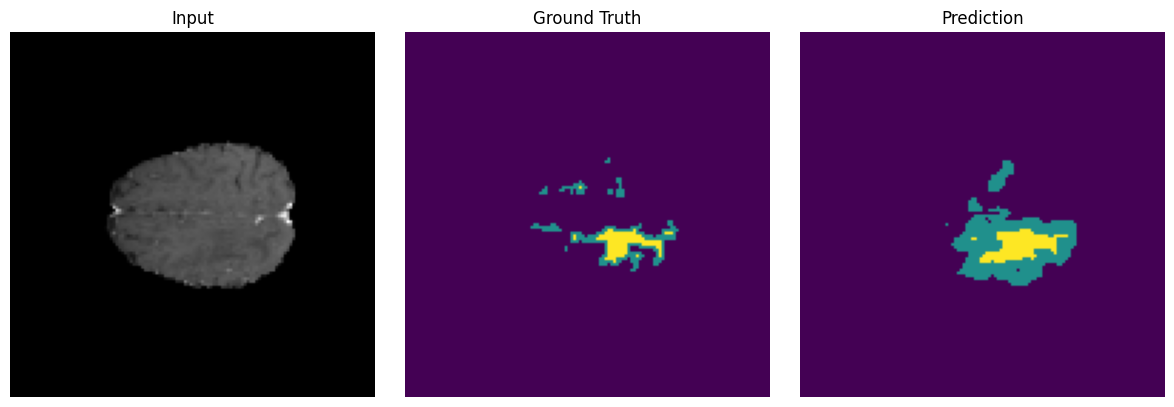

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


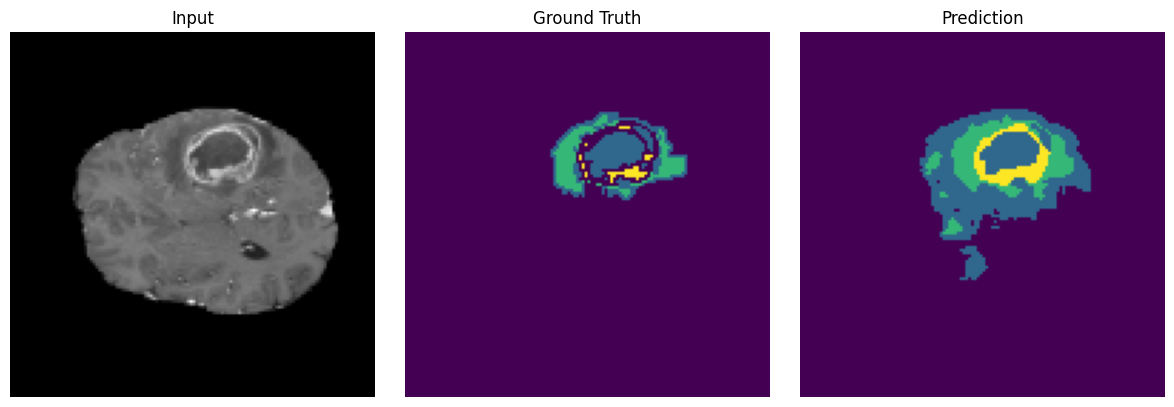

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


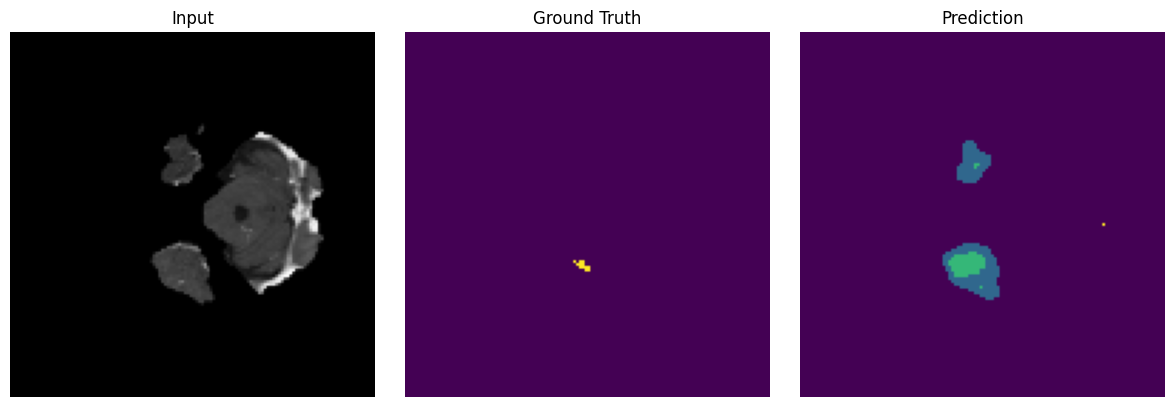

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


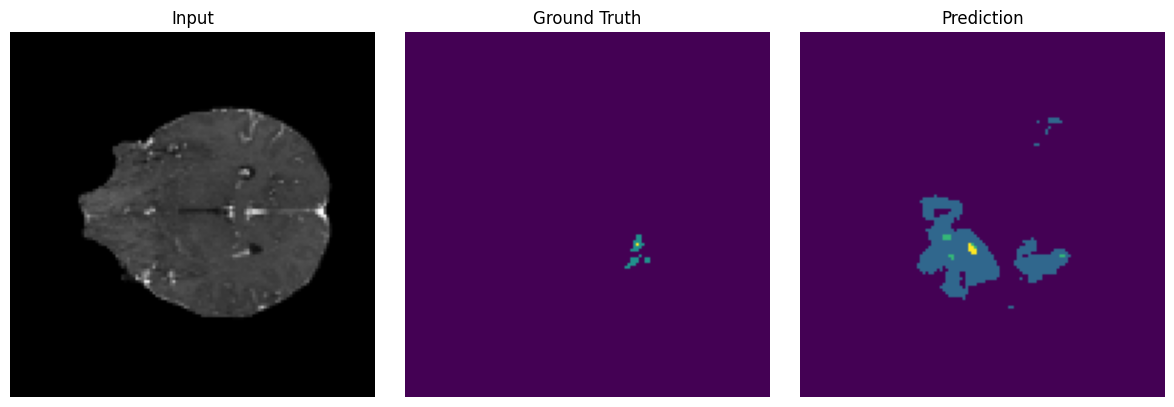

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


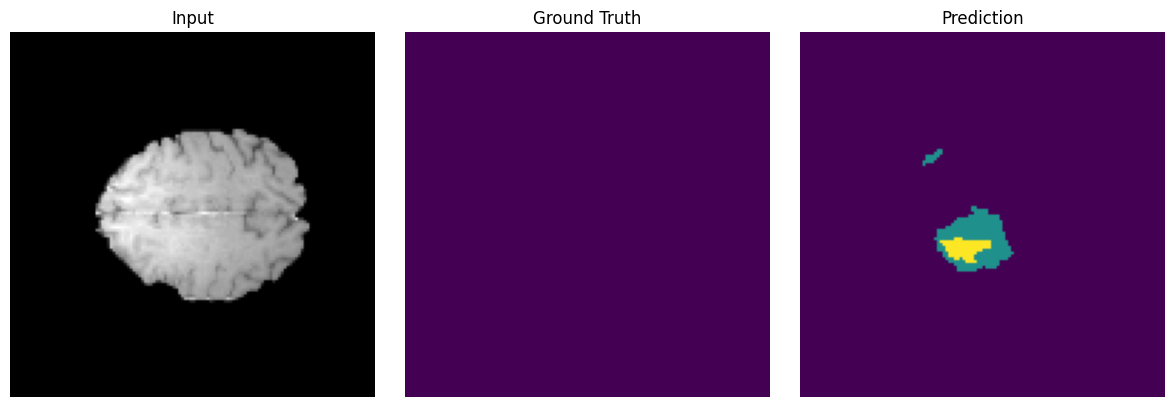

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


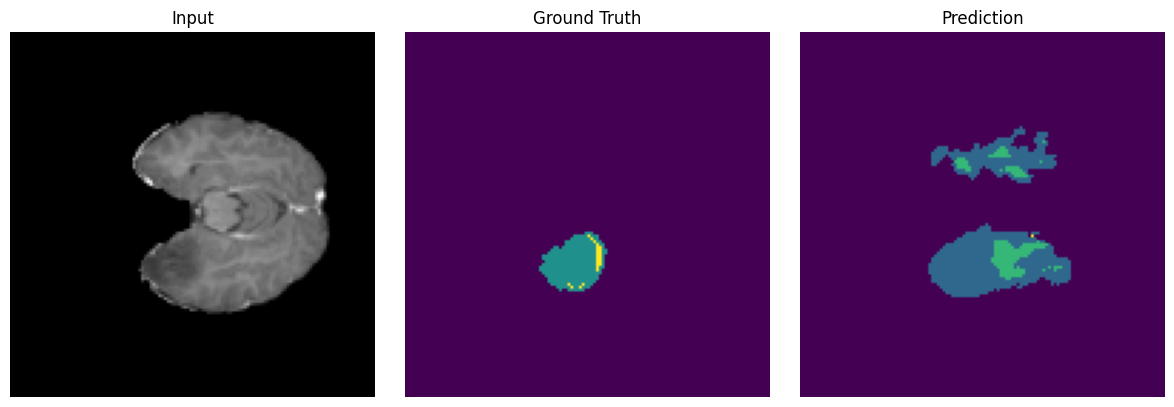

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


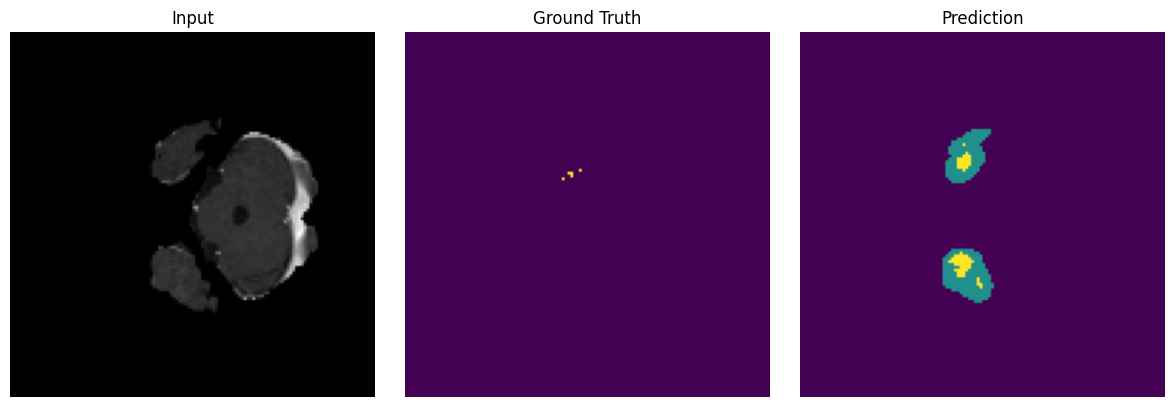

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


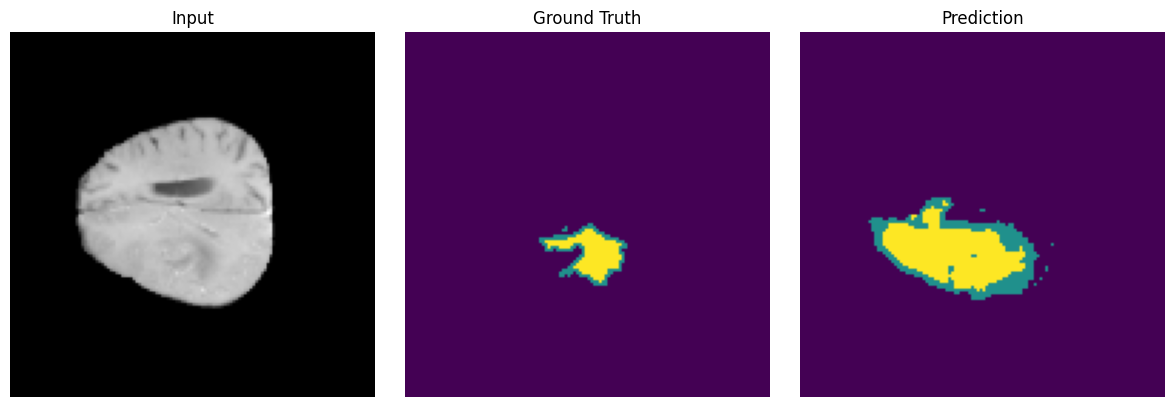

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


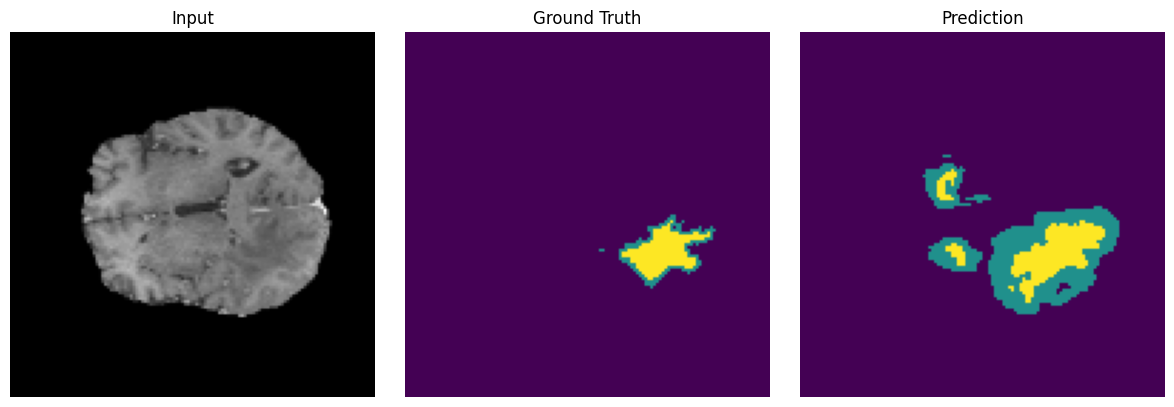

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


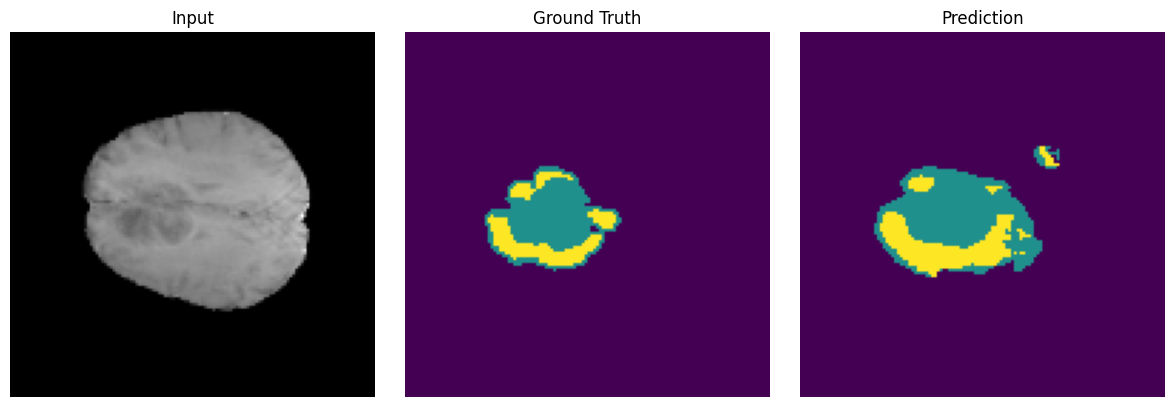

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


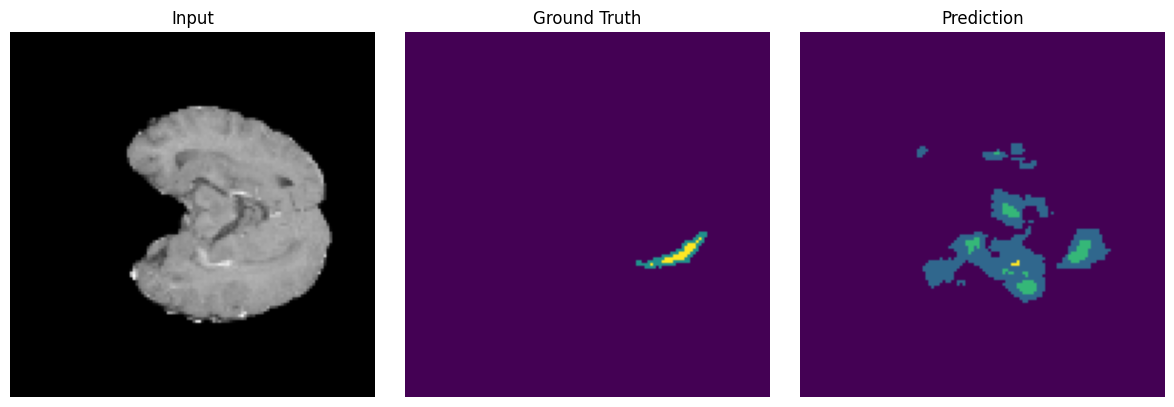

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


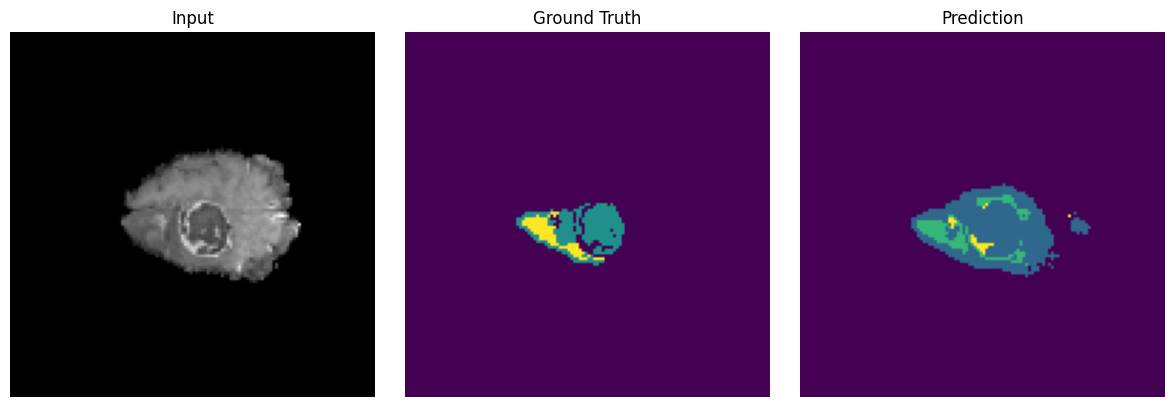

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


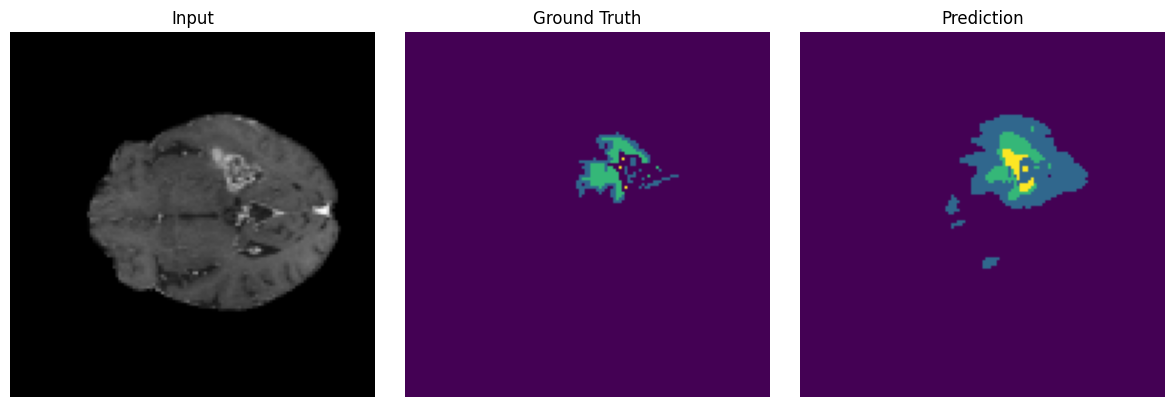

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


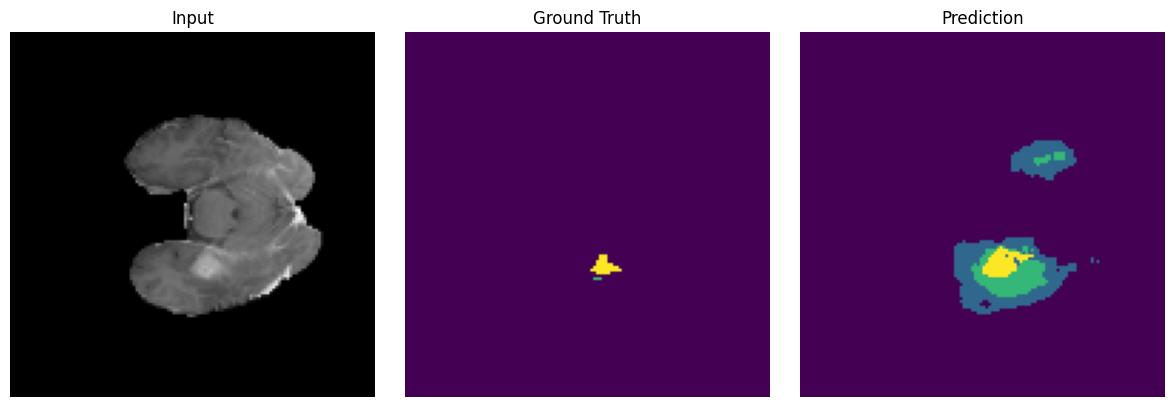

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


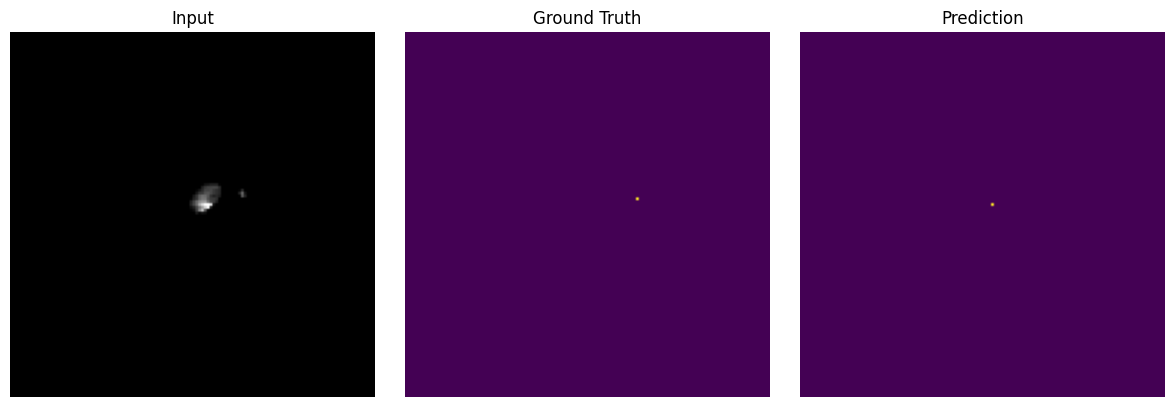

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


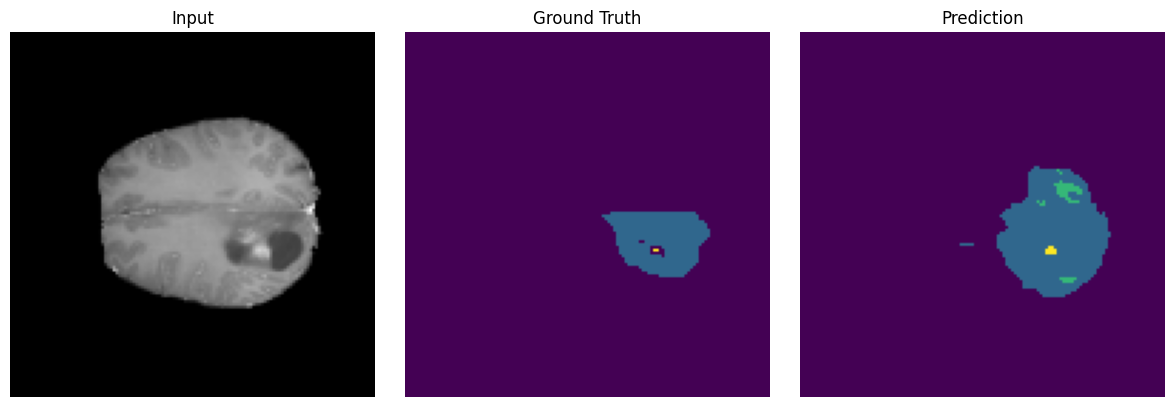

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


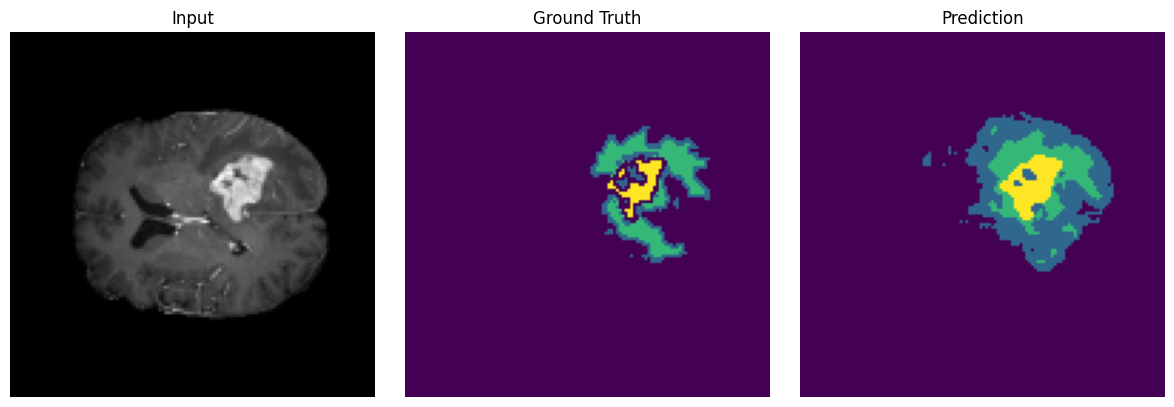

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


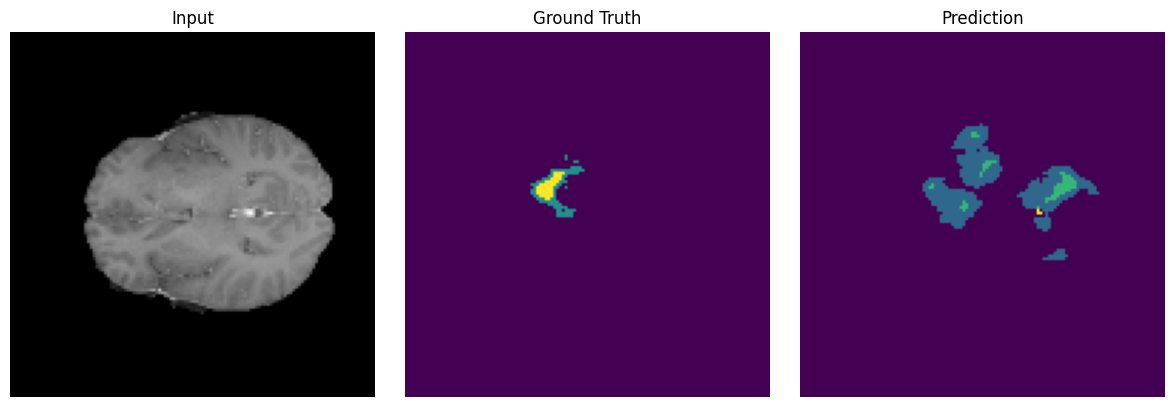

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


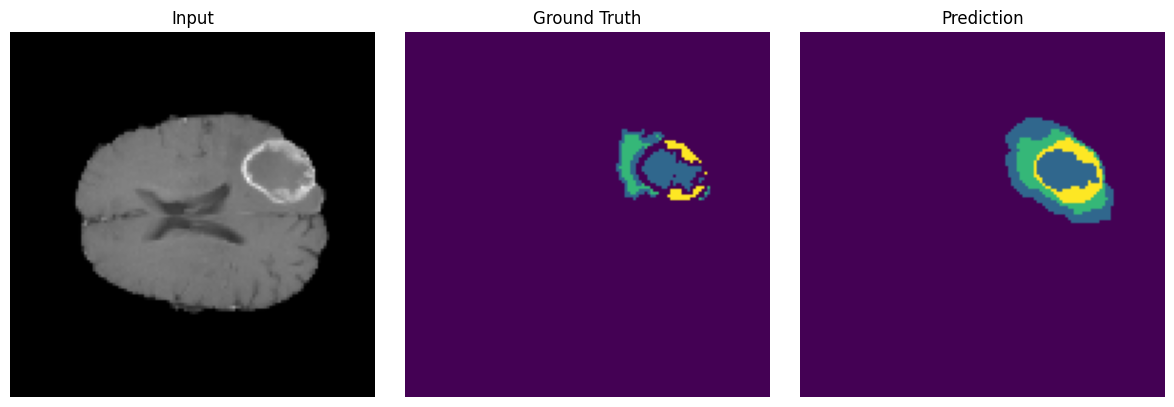

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


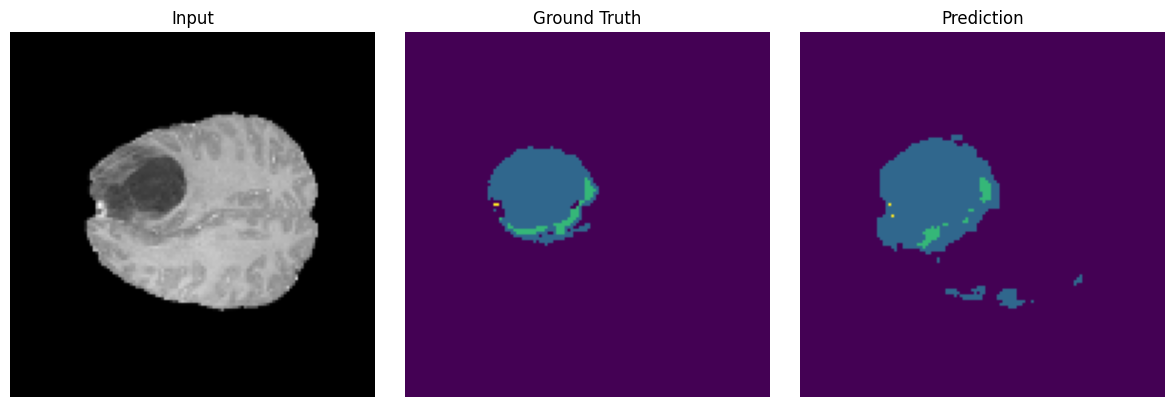

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


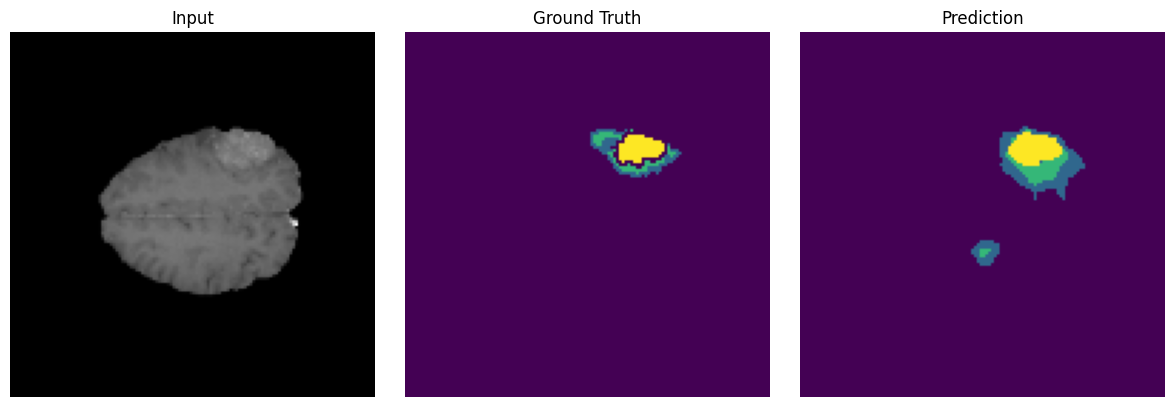

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


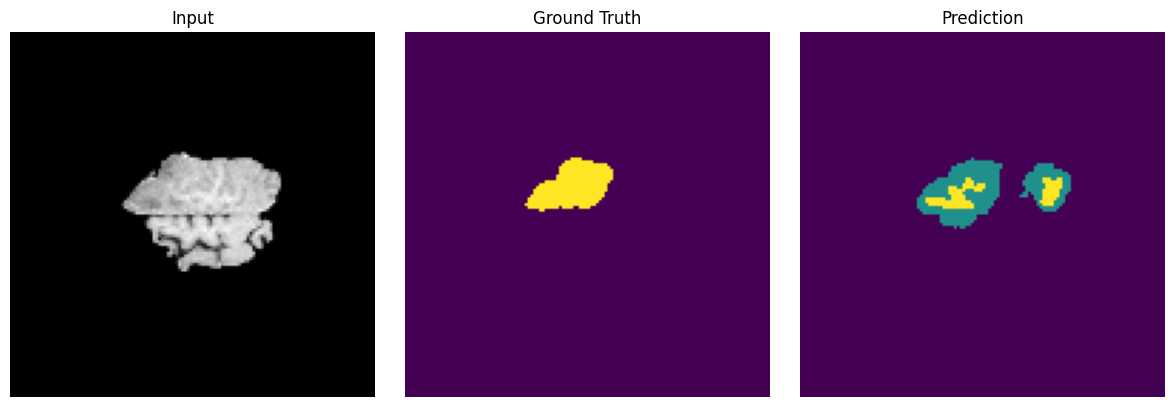

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


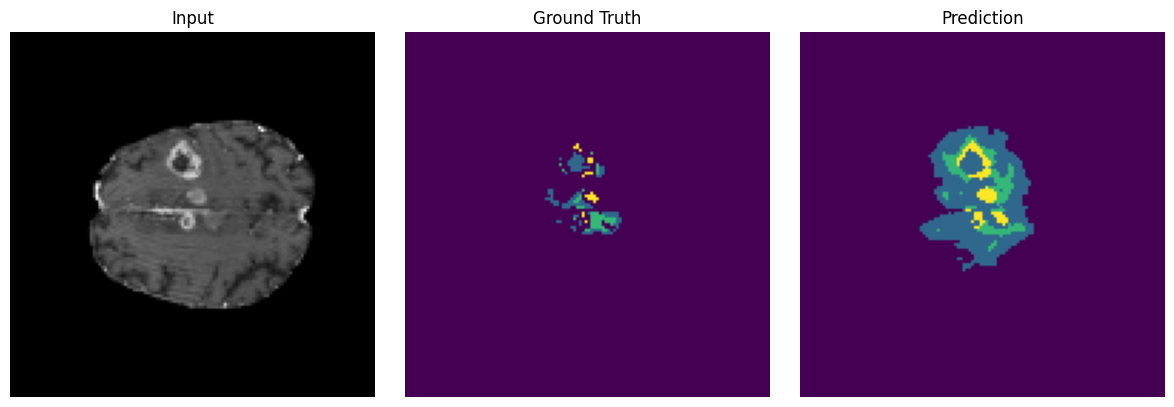

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


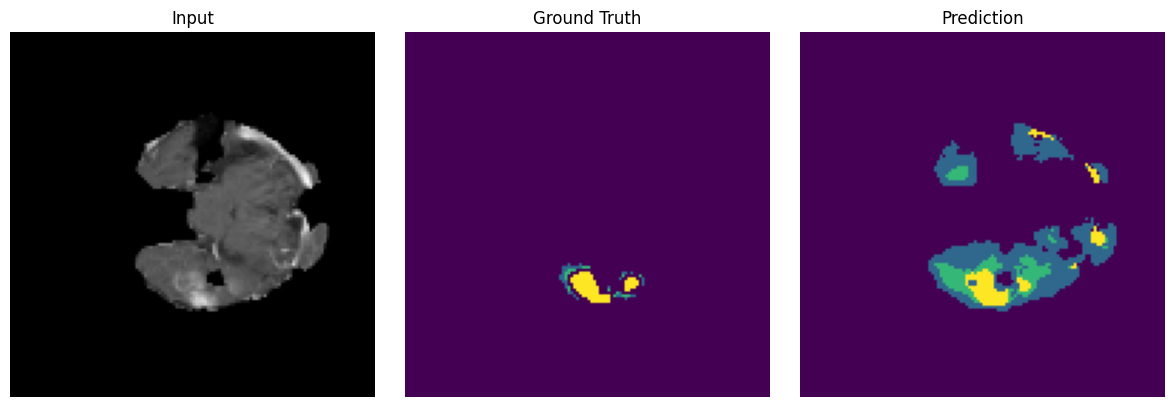

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


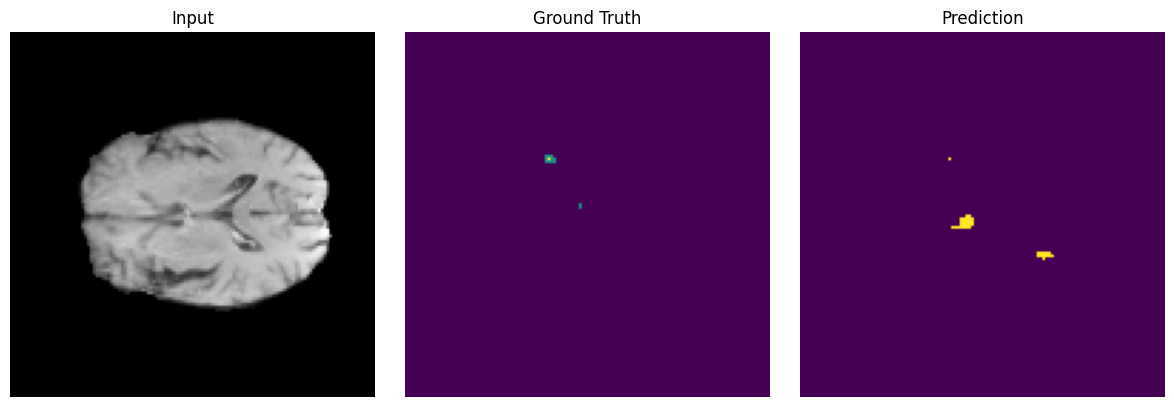

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


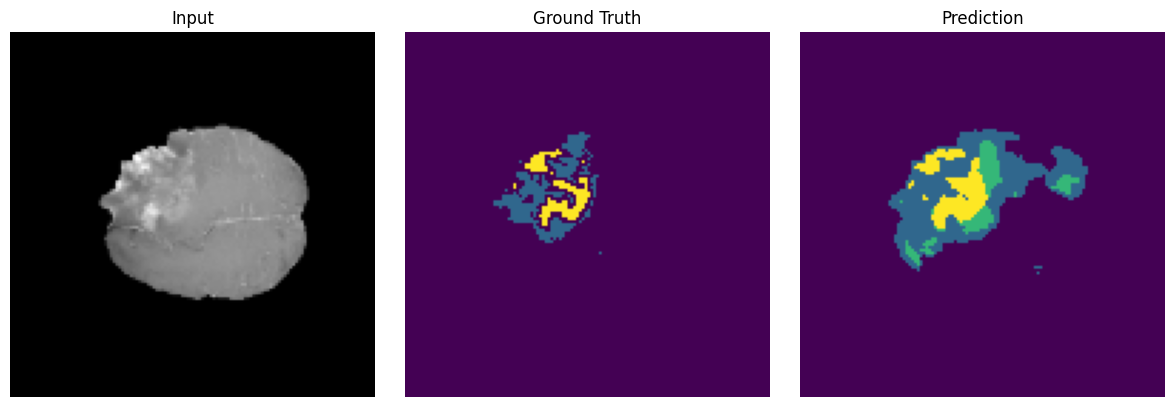

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


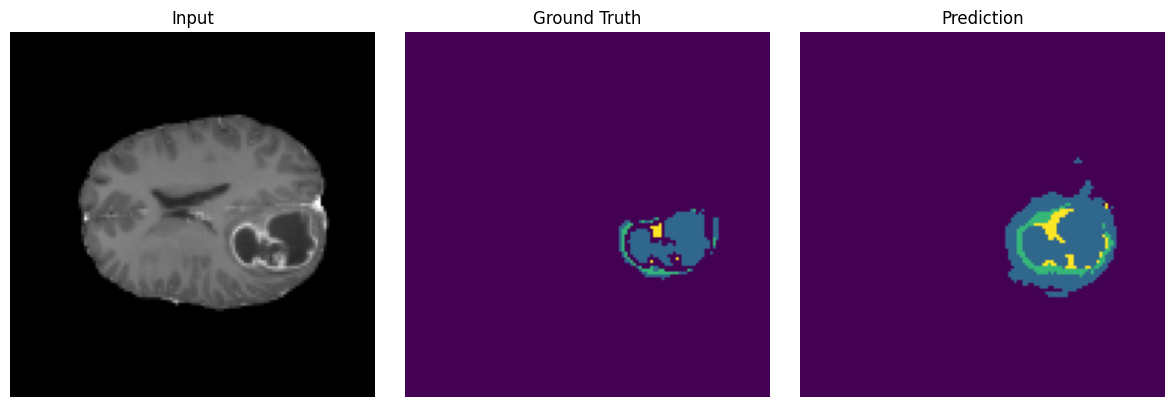

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


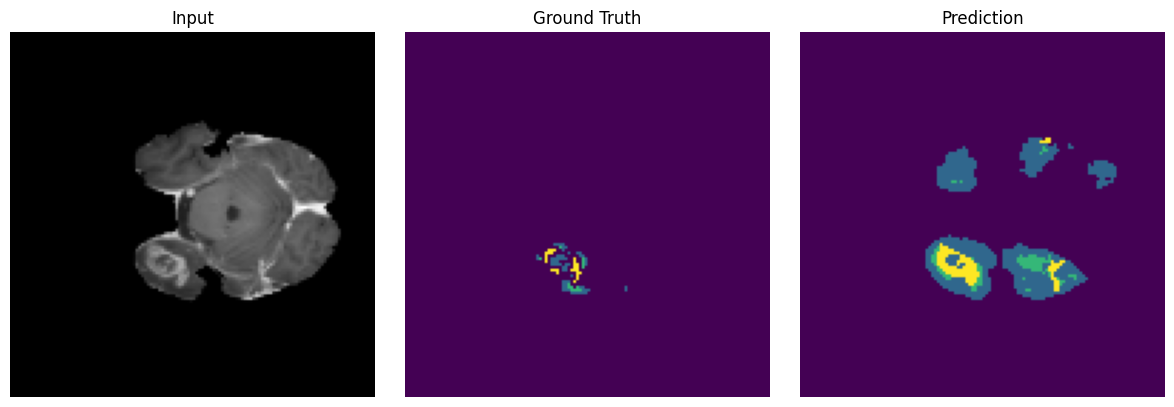

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


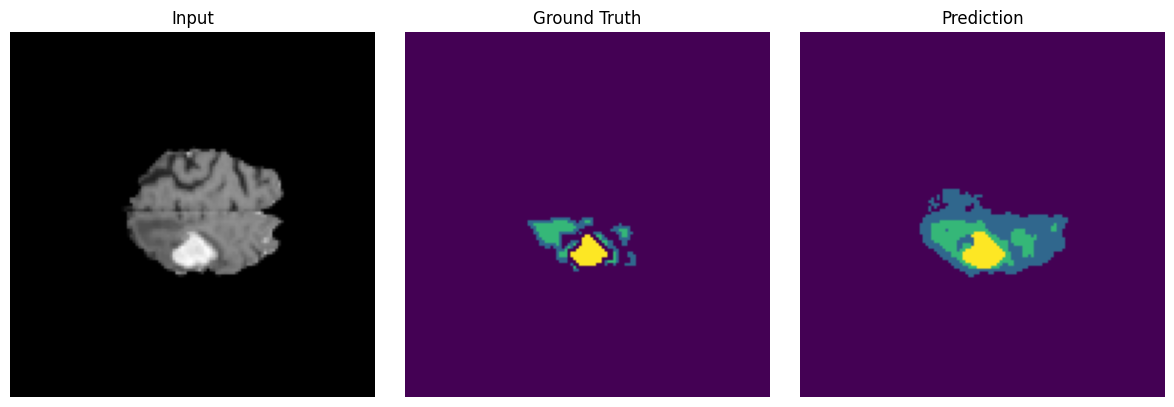

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


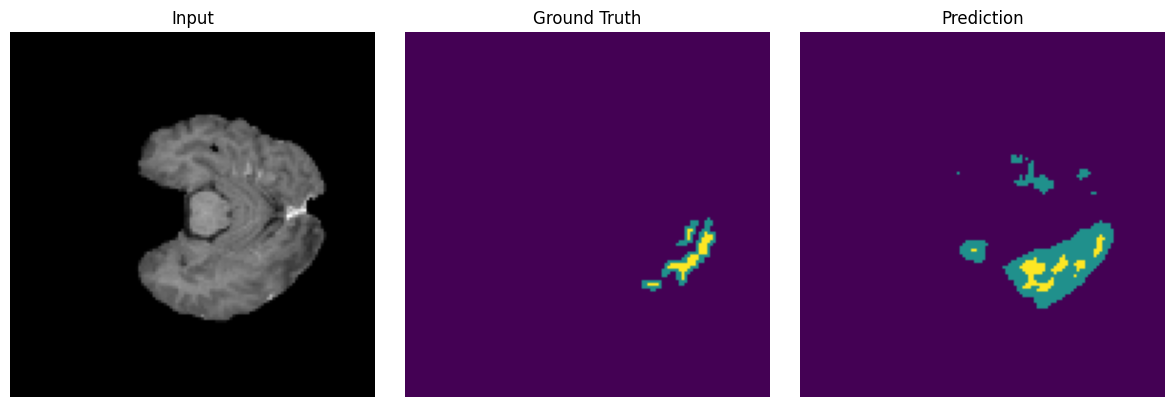

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model with custom loss
model = load_model(
    "unet_weighted_div.h5",
    custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
)

# Test on 30 random samples
num_samples = 30
indices = np.random.choice(len(X_val), num_samples, replace=False)

for i, idx in enumerate(indices):
    sample = X_val[idx:idx+1]  # shape (1, 128, 128, 1)
    true_mask = np.argmax(Y_val[idx], axis=-1)  # shape (128, 128)
    pred = model.predict(sample)
    pred_mask = np.argmax(pred[0], axis=-1)     # shape (128, 128)

    # Plot input, ground truth, prediction
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(sample[0, :, :, 0], cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='viridis')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='viridis')
    plt.title("Prediction")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

✅ Found existing checkpoint, loading model...


Epoch 50/61
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9503 - loss: 0.2383

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


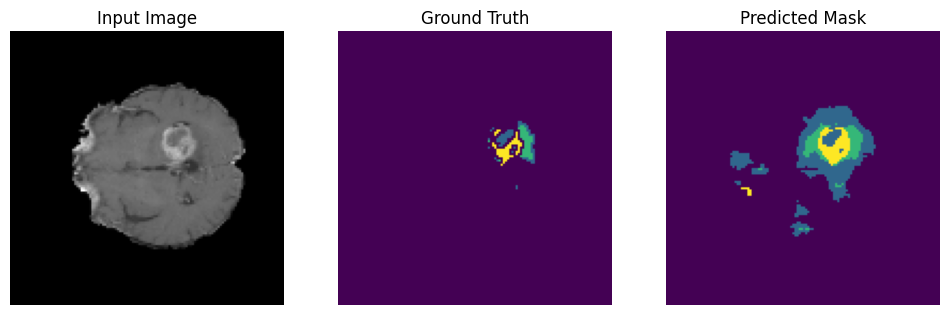

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 390s 140ms/step - accuracy: 0.9503 - loss: 0.2383 - val_accuracy: 0.9491 - val_loss: 0.2806
Epoch 51/61
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9503 - loss: 0.2394

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


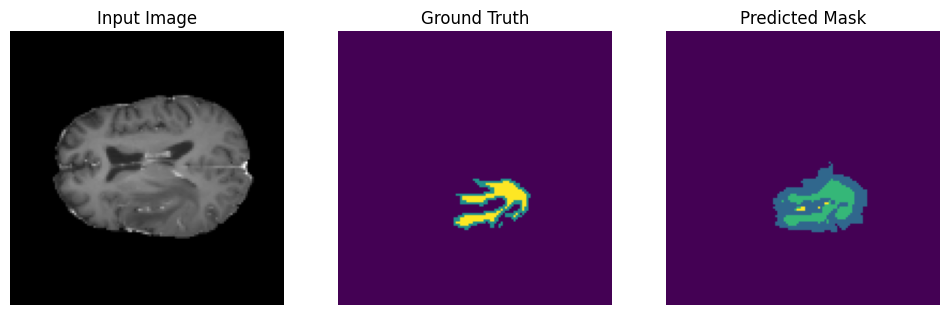

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 381s 139ms/step - accuracy: 0.9503 - loss: 0.2394 - val_accuracy: 0.9485 - val_loss: 0.2806
Epoch 52/61
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9503 - loss: 0.2383

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


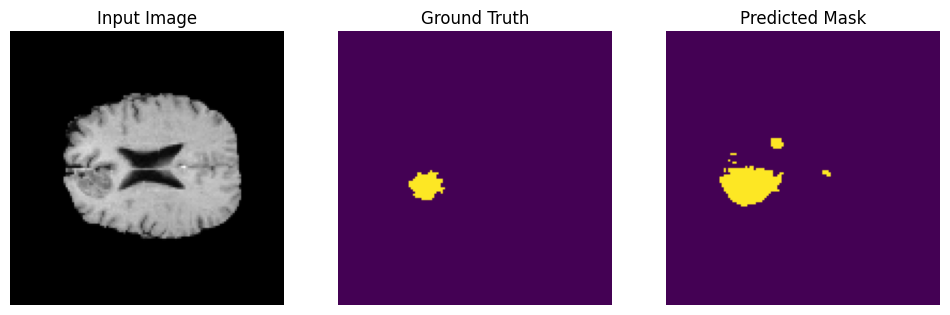

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 378s 138ms/step - accuracy: 0.9503 - loss: 0.2383 - val_accuracy: 0.9484 - val_loss: 0.2805
Epoch 53/61
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9502 - loss: 0.2381

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


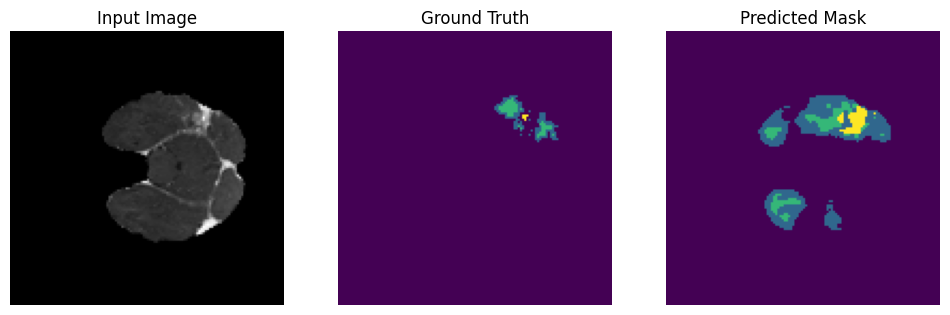

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 383s 140ms/step - accuracy: 0.9502 - loss: 0.2381 - val_accuracy: 0.9493 - val_loss: 0.2805
Epoch 54/61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


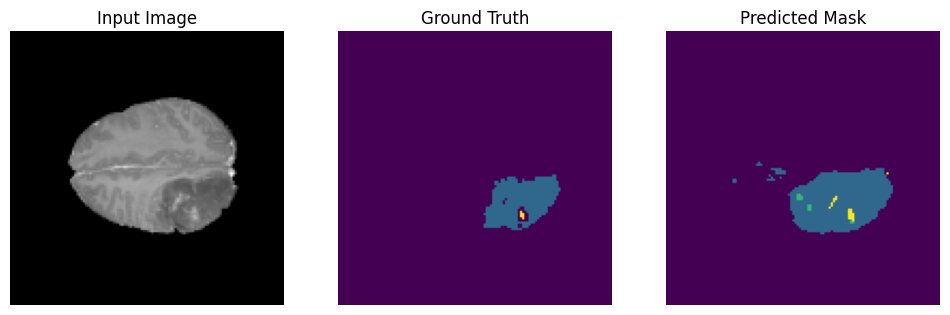

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 381s 139ms/step - accuracy: 0.9499 - loss: 0.2400 - val_accuracy: 0.9499 - val_loss: 0.2806
Epoch 55/61
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9502 - loss: 0.2390

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


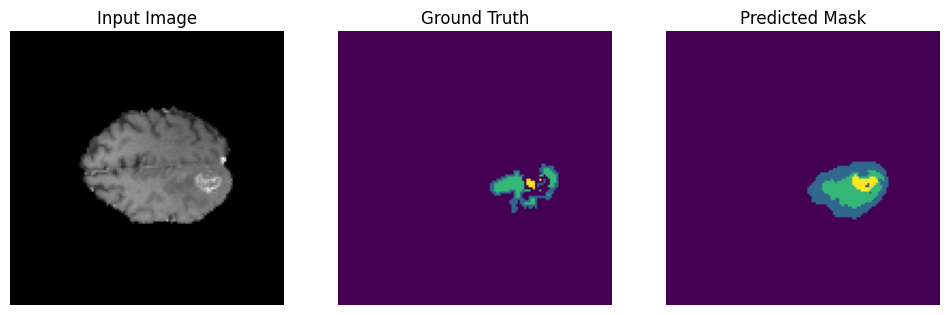

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 397s 145ms/step - accuracy: 0.9502 - loss: 0.2390 - val_accuracy: 0.9485 - val_loss: 0.2801
Epoch 56/61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


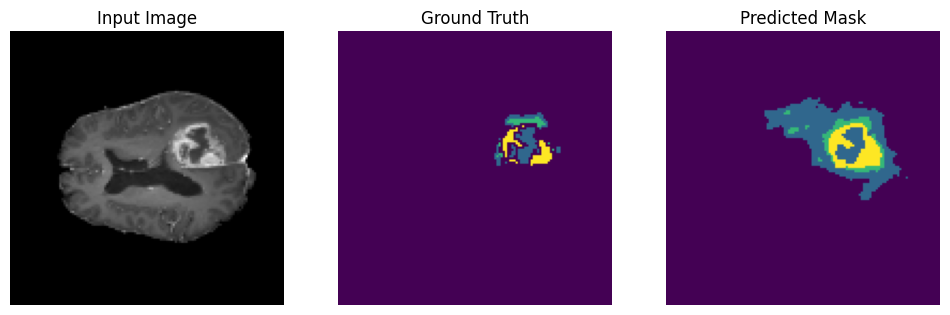

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 382s 139ms/step - accuracy: 0.9502 - loss: 0.2387 - val_accuracy: 0.9490 - val_loss: 0.2804
Epoch 57/61
2740/2740 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9506 - loss: 0.2375

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


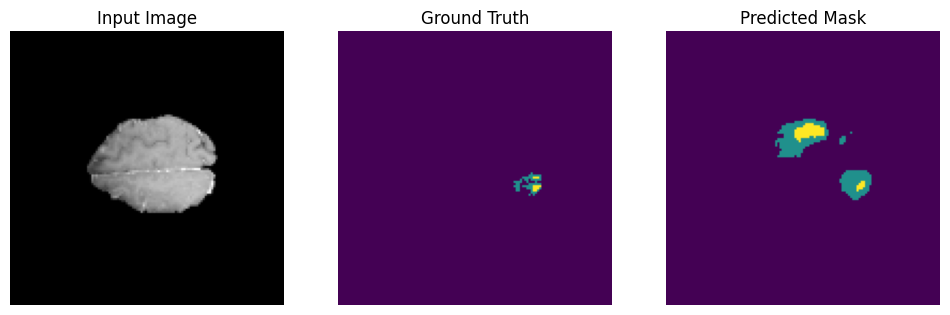

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 385s 141ms/step - accuracy: 0.9506 - loss: 0.2375 - val_accuracy: 0.9476 - val_loss: 0.2799
Epoch 58/61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


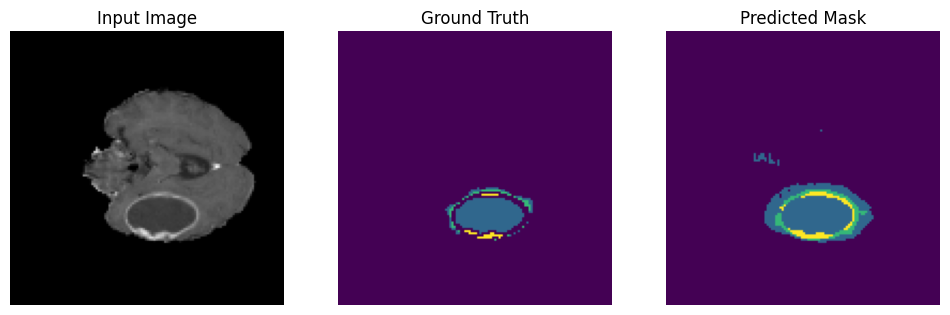

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 387s 141ms/step - accuracy: 0.9506 - loss: 0.2367 - val_accuracy: 0.9489 - val_loss: 0.2802
Epoch 59/61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


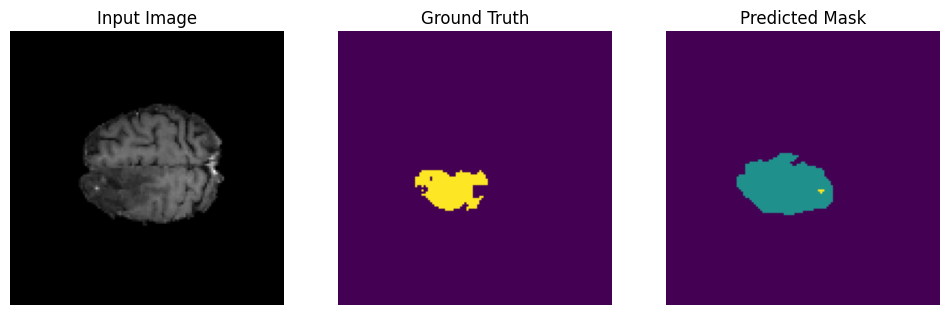

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 385s 141ms/step - accuracy: 0.9506 - loss: 0.2375 - val_accuracy: 0.9499 - val_loss: 0.2809
Epoch 60/61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


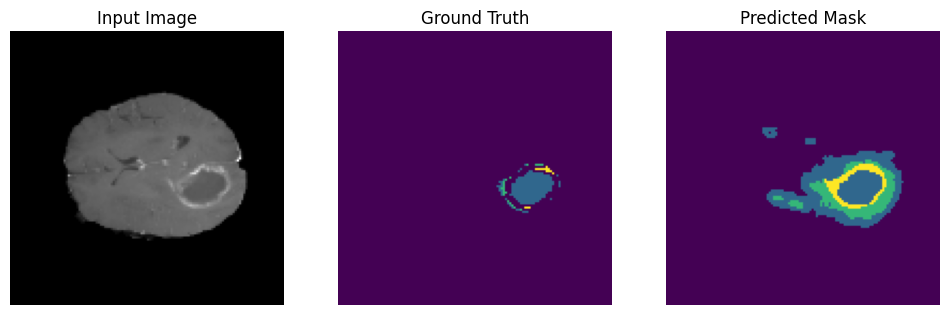

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 381s 139ms/step - accuracy: 0.9505 - loss: 0.2380 - val_accuracy: 0.9496 - val_loss: 0.2804
Epoch 61/61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


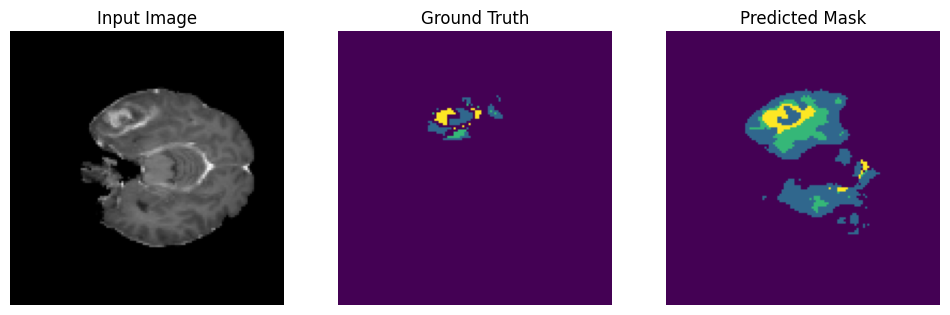

2740/2740 ━━━━━━━━━━━━━━━━━━━━ 387s 141ms/step - accuracy: 0.9508 - loss: 0.2354 - val_accuracy: 0.9508 - val_loss: 0.2811


In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# -------------------------
# 1. Paths and Settings
# -------------------------
checkpoint_path = "unet_weighted_div.h5"
initial_epoch = 0

# -------------------------
# 2. Load Data
# -------------------------
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]

# -------------------------
# 3. Custom Weighted Loss (Same as before)
# -------------------------
class_weights_tensor = tf.constant([0.25, 19.03, 34.29, 206.04], dtype=tf.float32)

def weighted_categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    weights = tf.reduce_sum(class_weights_tensor * y_true, axis=-1)
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return loss * weights

# -------------------------
# 4. Prediction Callback (Shows Input, Ground Truth, Prediction)
# -------------------------
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.randint(0, len(X_val))
        sample = X_val[idx:idx+1]
        pred = np.argmax(self.model.predict(sample), axis=-1)[0]
        true_mask = np.argmax(Y_val[idx], axis=-1)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(sample[0, :, :, 0], cmap='gray')
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask, cmap='viridis')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap='viridis')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

# -------------------------
# 5. Load Model if Checkpoint Exists
# -------------------------
if os.path.exists(checkpoint_path):
    print("✅ Found existing checkpoint, loading model...")
    model = load_model(
        checkpoint_path,
        custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss=weighted_categorical_crossentropy,
                  metrics=['accuracy'])
    initial_epoch = 49 # update this to last epoch you trained
else:
    print("❌ No checkpoint found! Cannot fine-tune without base model.")
    raise SystemExit("Train initial model first!")

# -------------------------
# 6. Callbacks
# -------------------------
checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# -------------------------
# 7. Resume Training (Add 25 More Epochs)
# -------------------------
model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    initial_epoch=initial_epoch,
    epochs=initial_epoch + 12,  # continue for 25 more epochs
    batch_size=8,
    callbacks=[checkpoint, early_stop, PredictionCallback()]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step


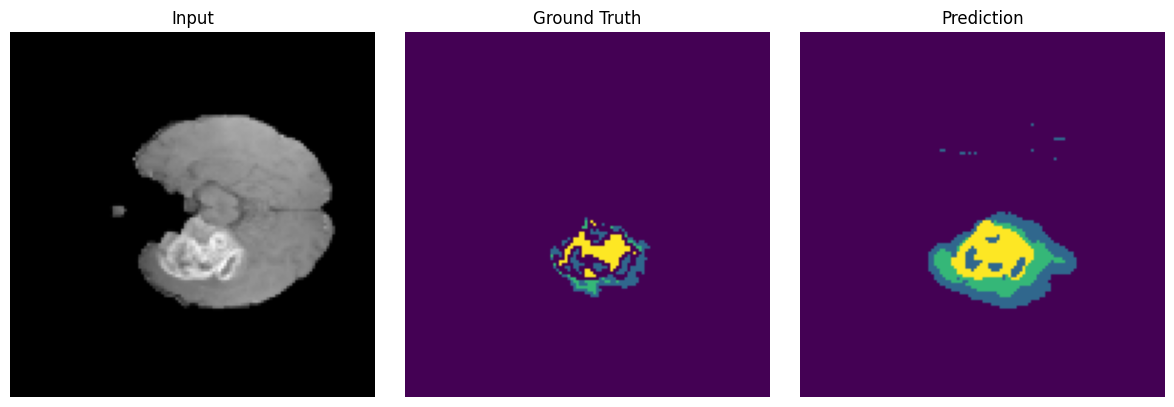

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


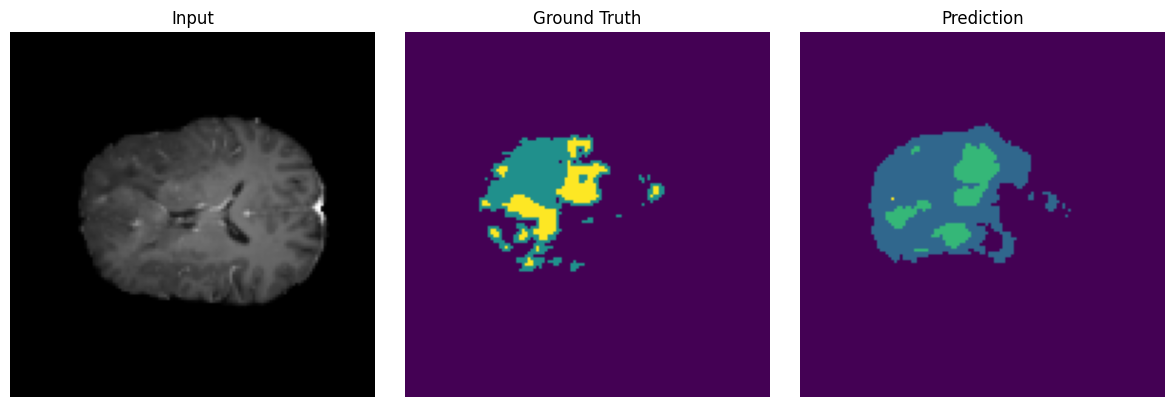

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


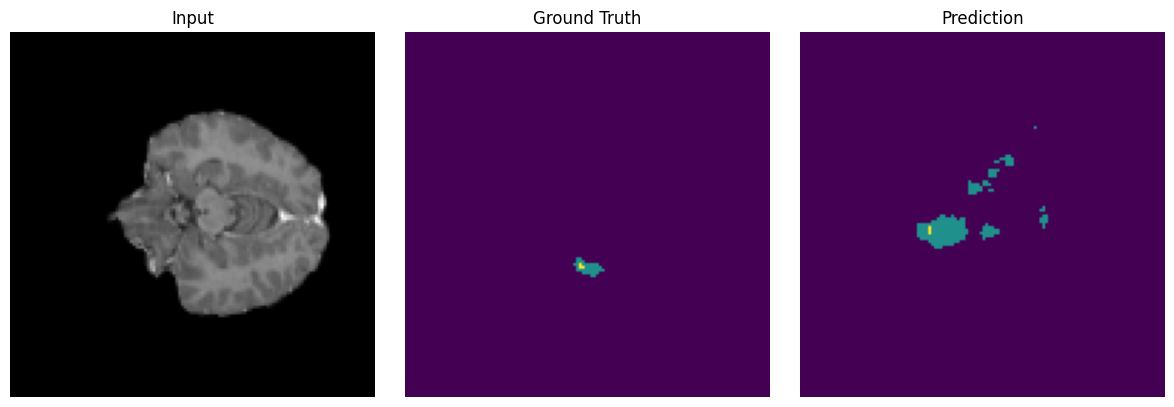

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


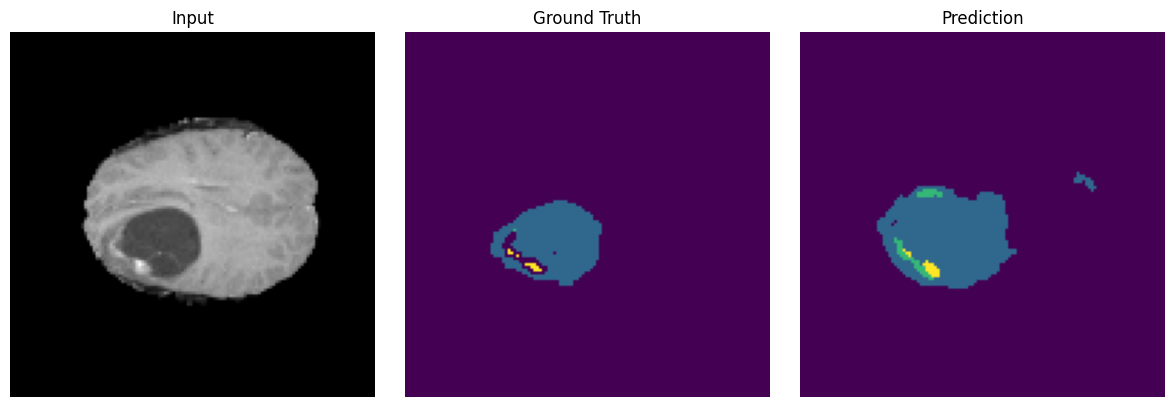

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


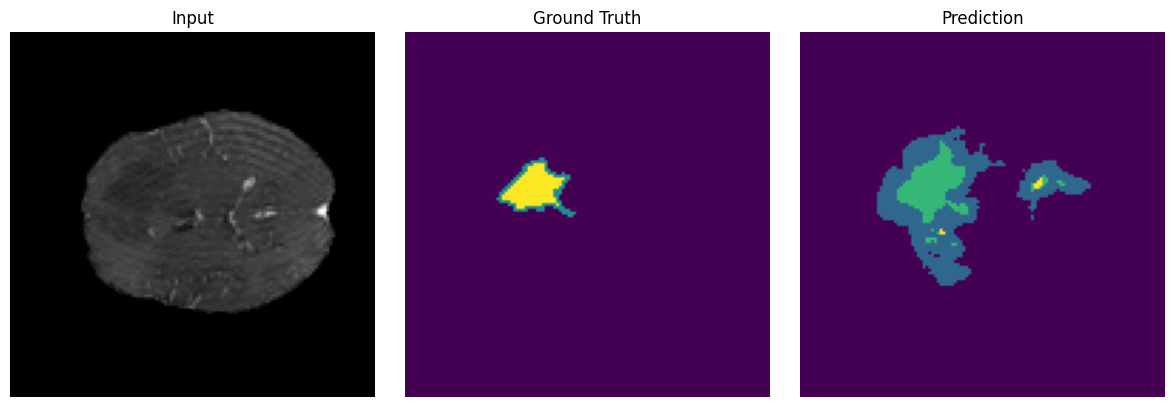

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


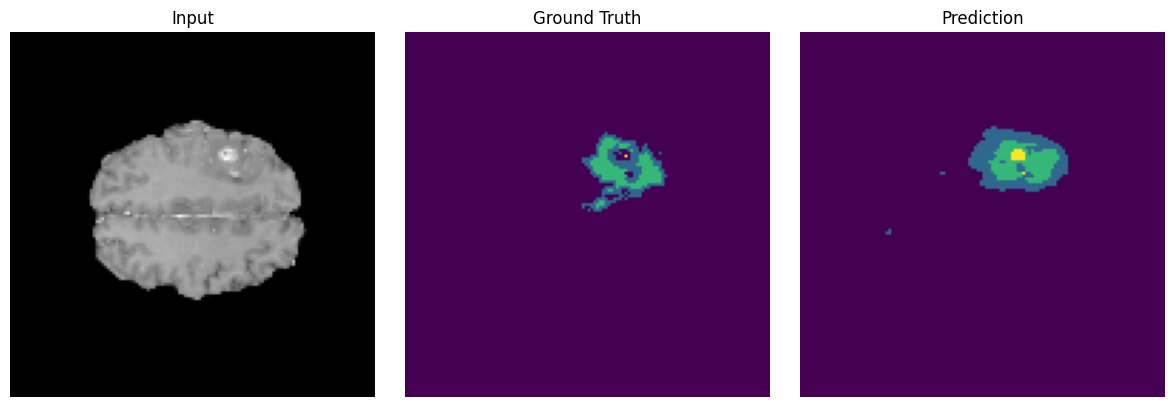

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


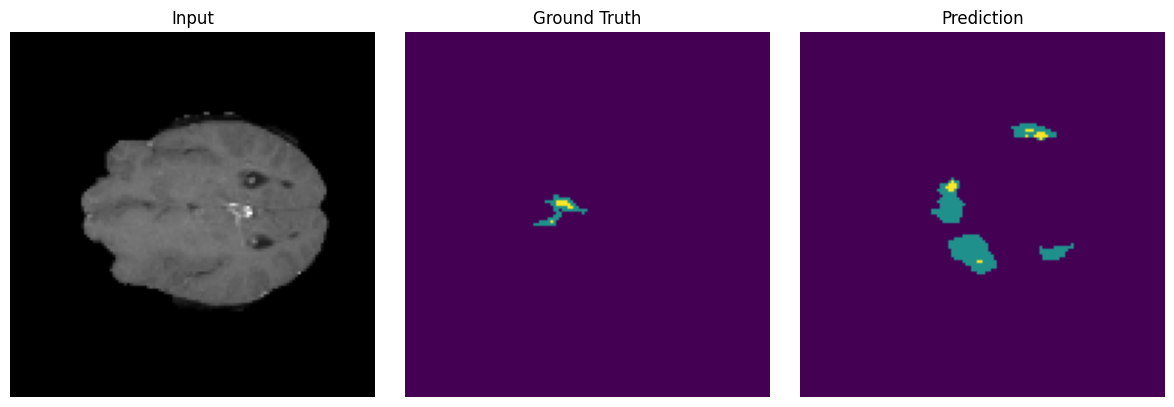

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


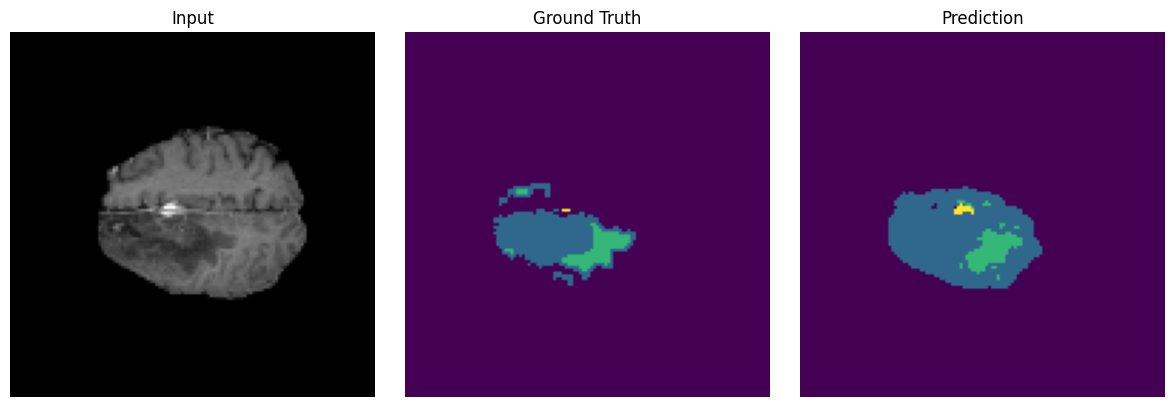

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


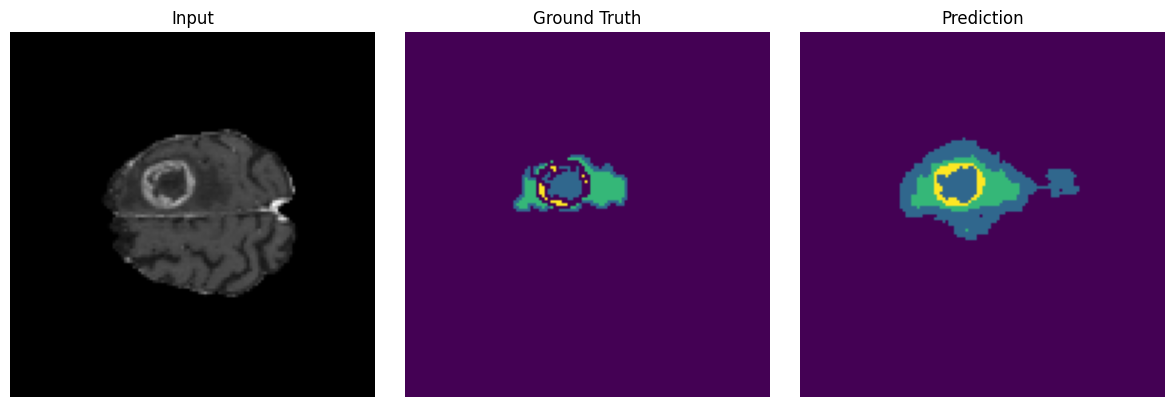

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


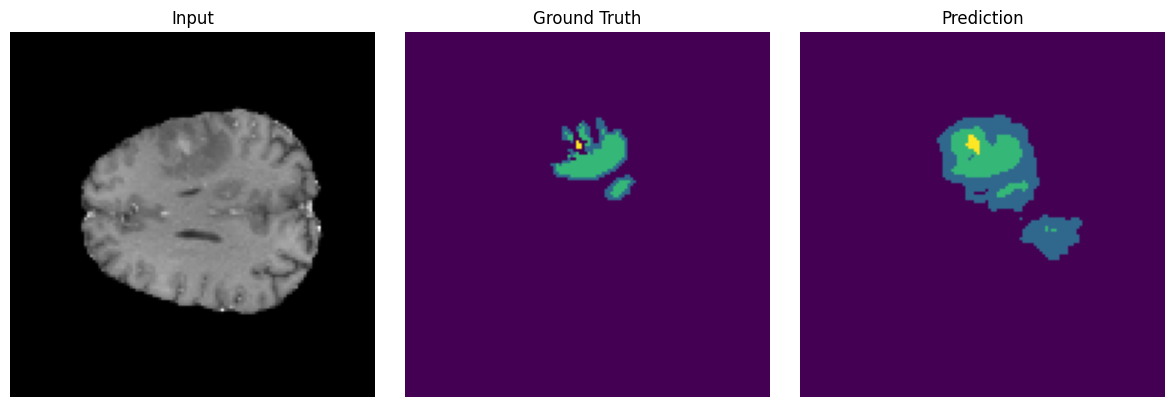

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


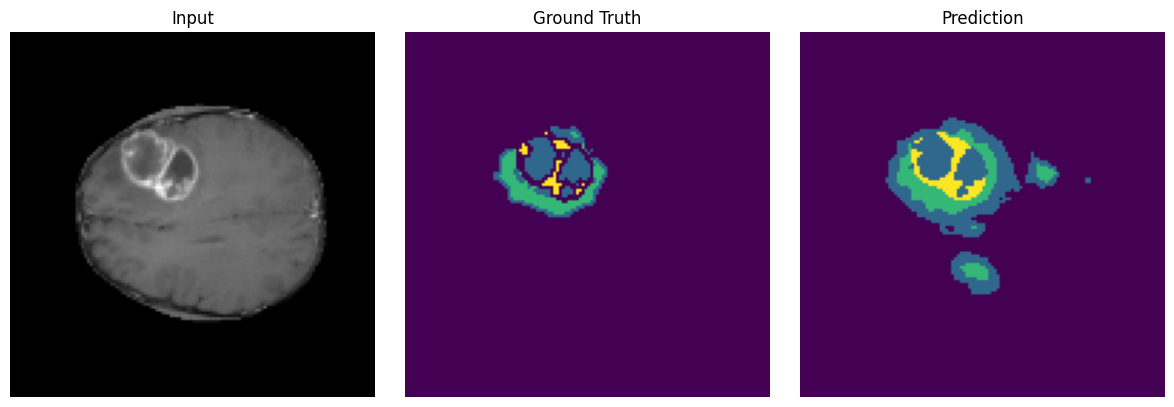

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


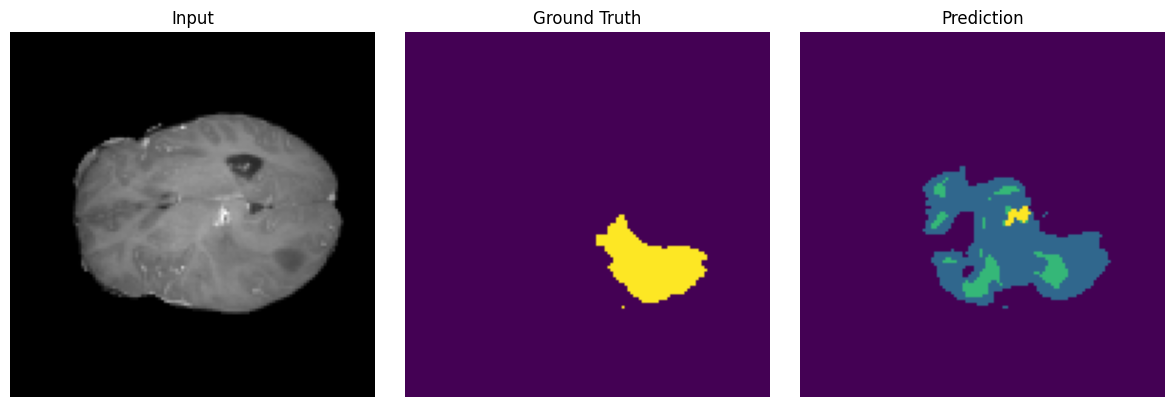

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


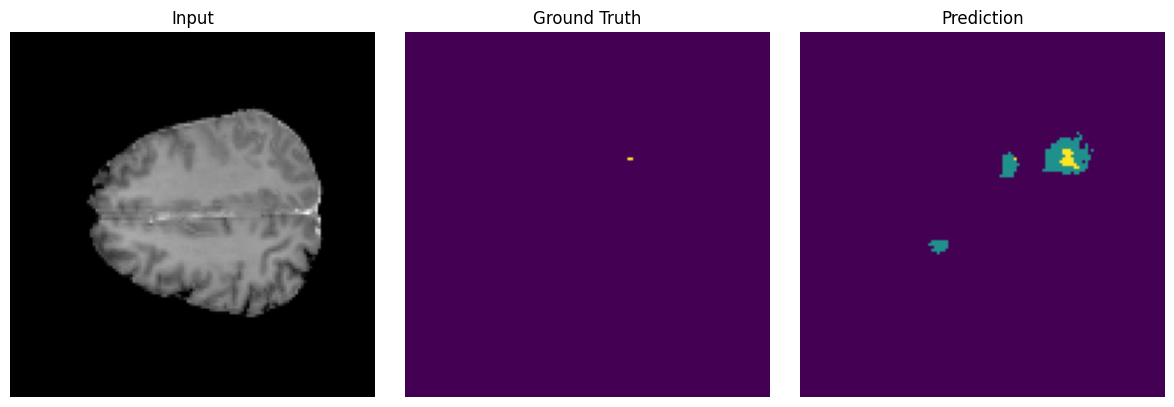

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


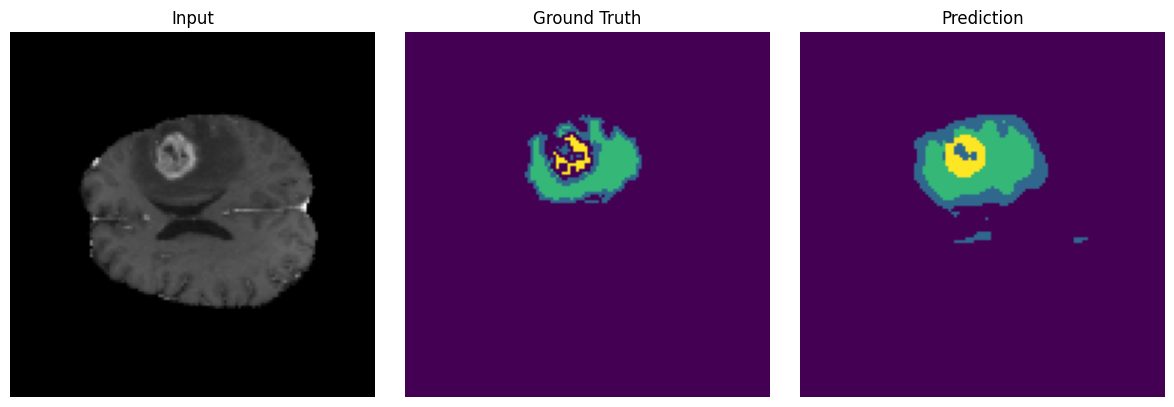

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


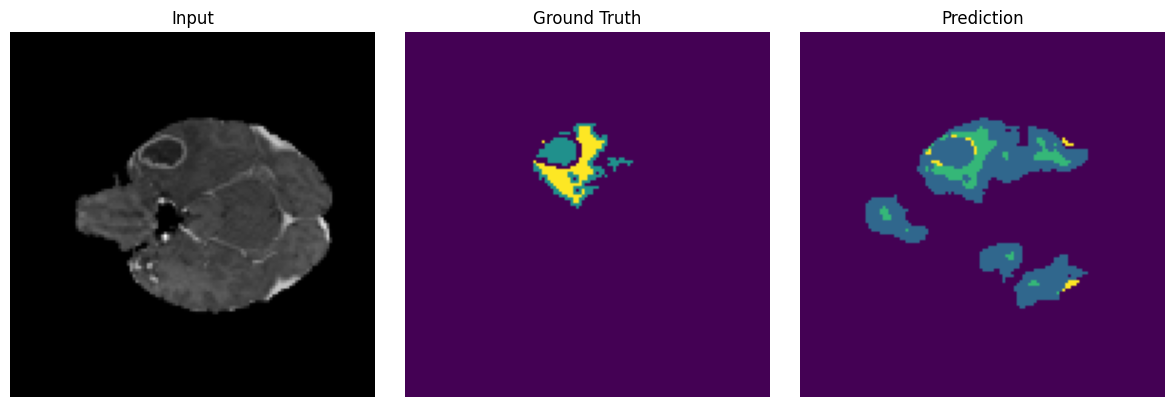

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


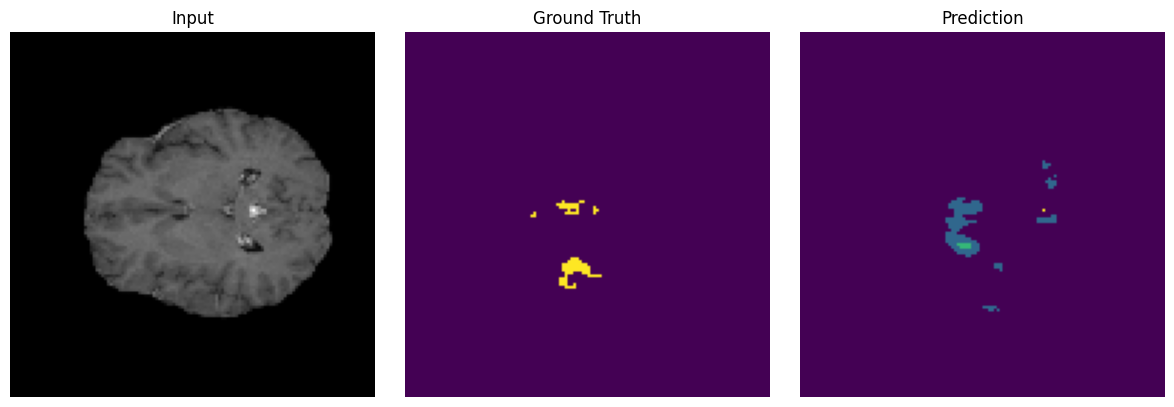

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


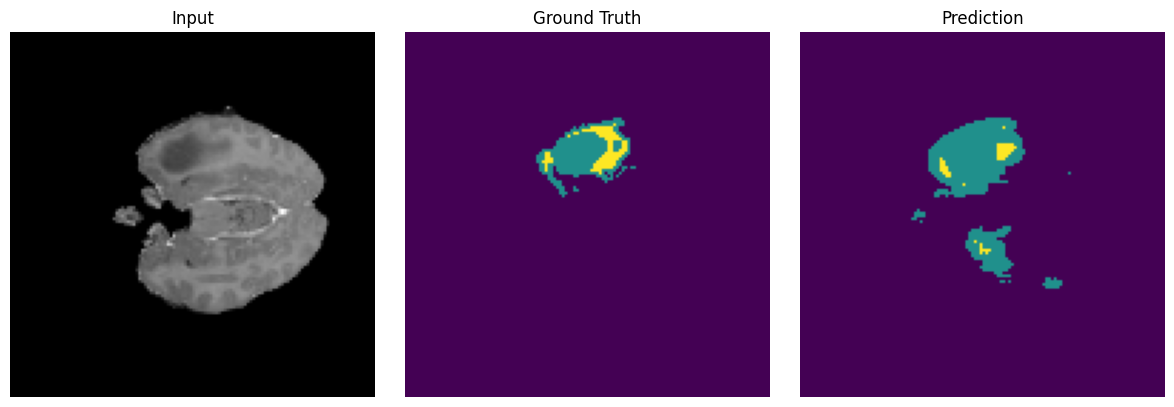

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


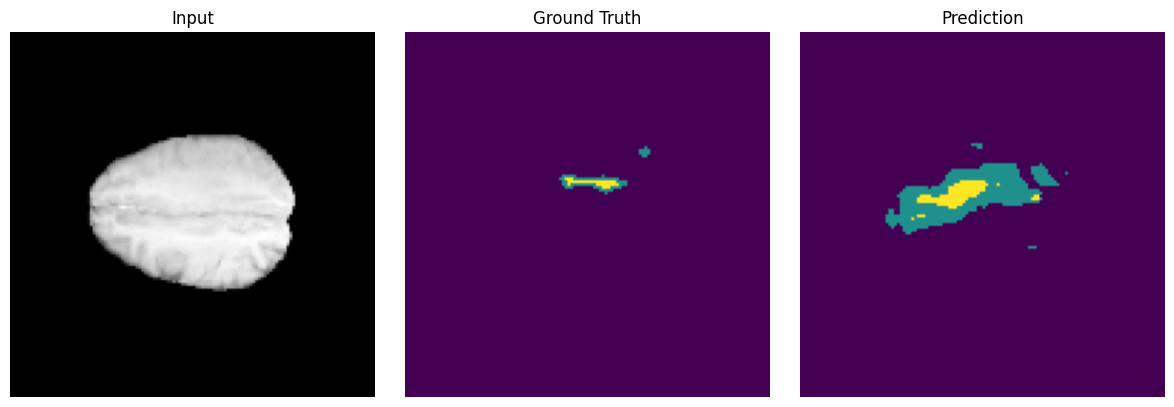

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


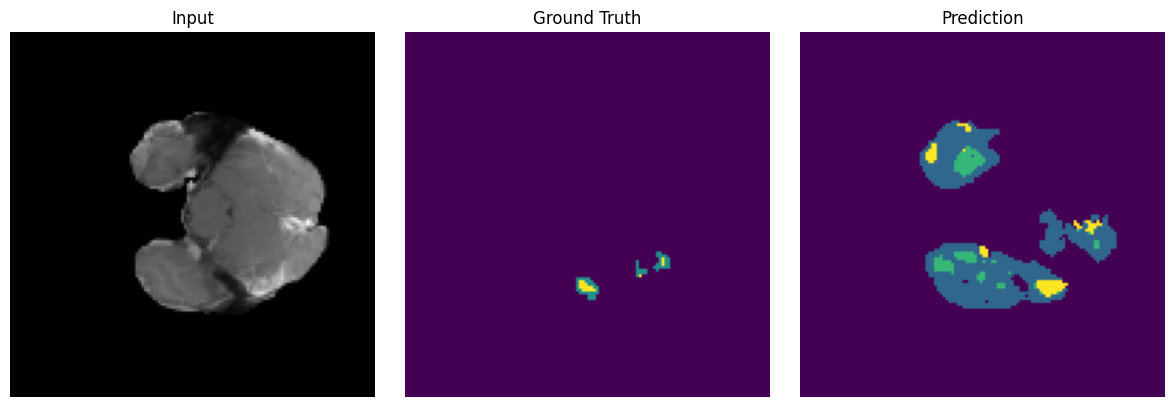

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


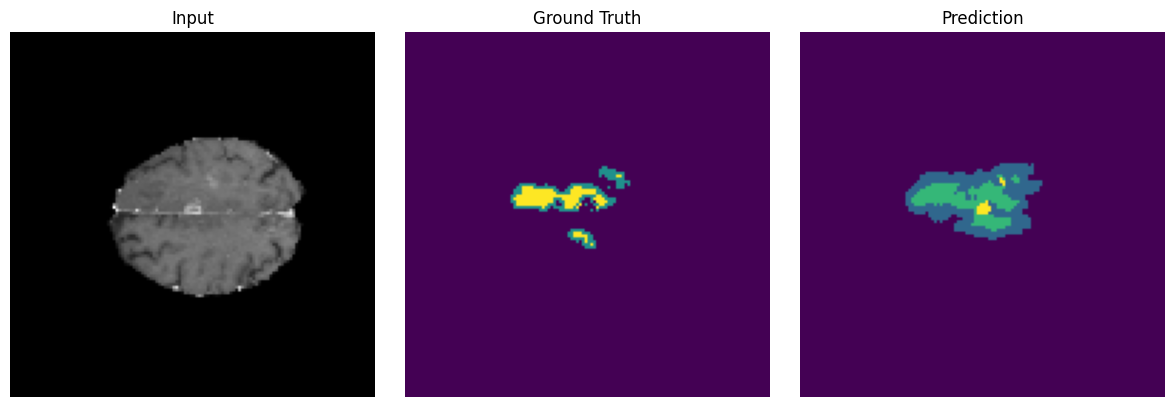

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


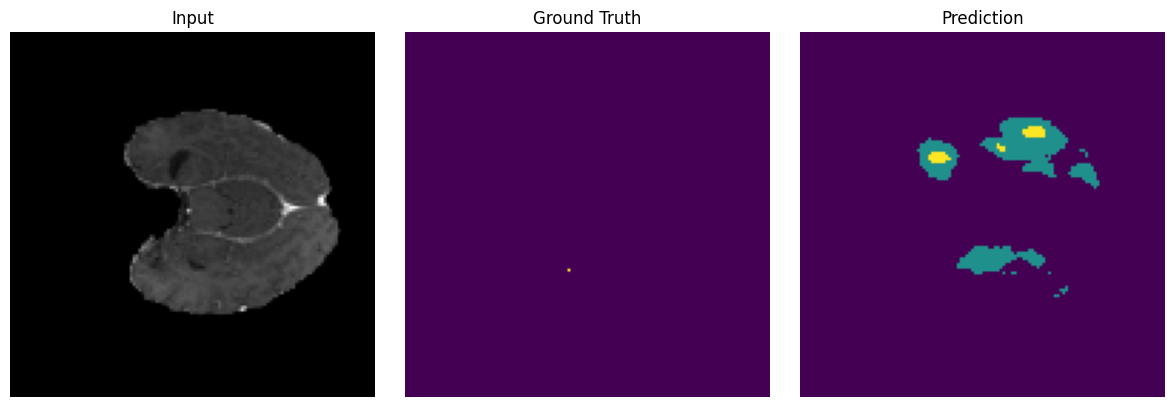

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


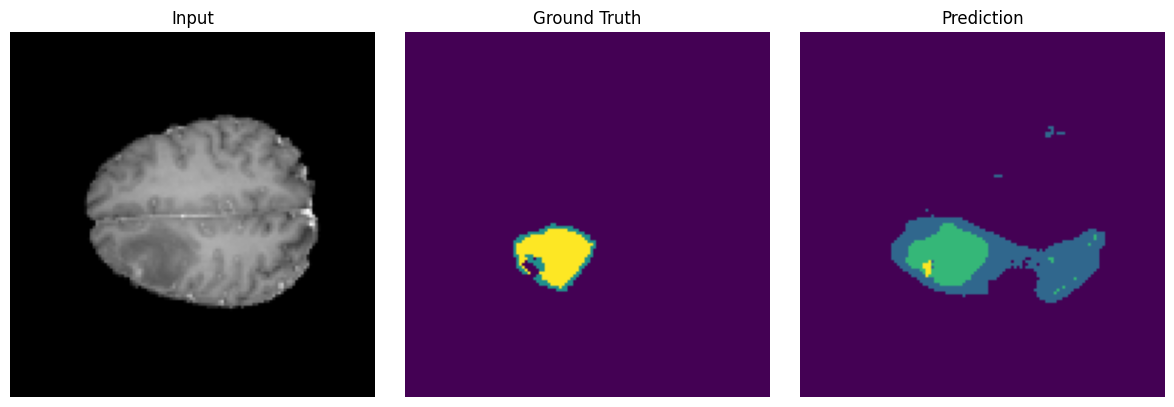

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


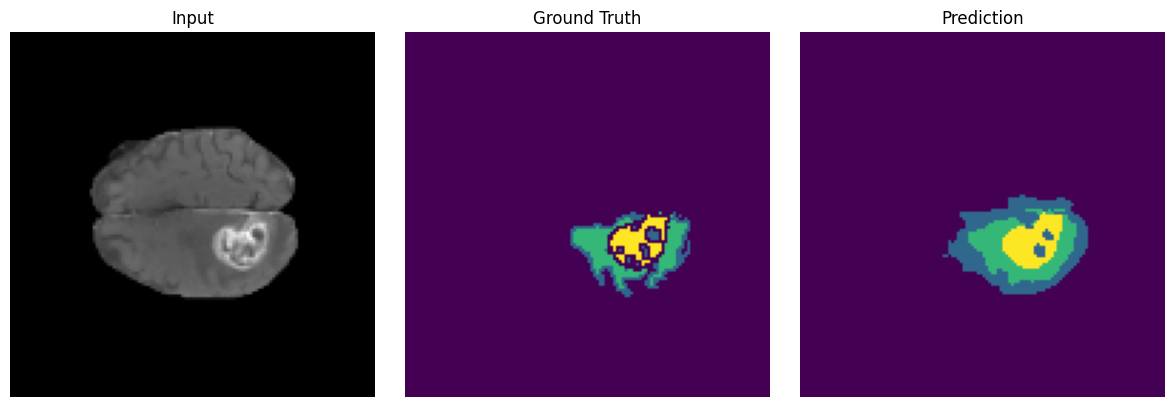

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


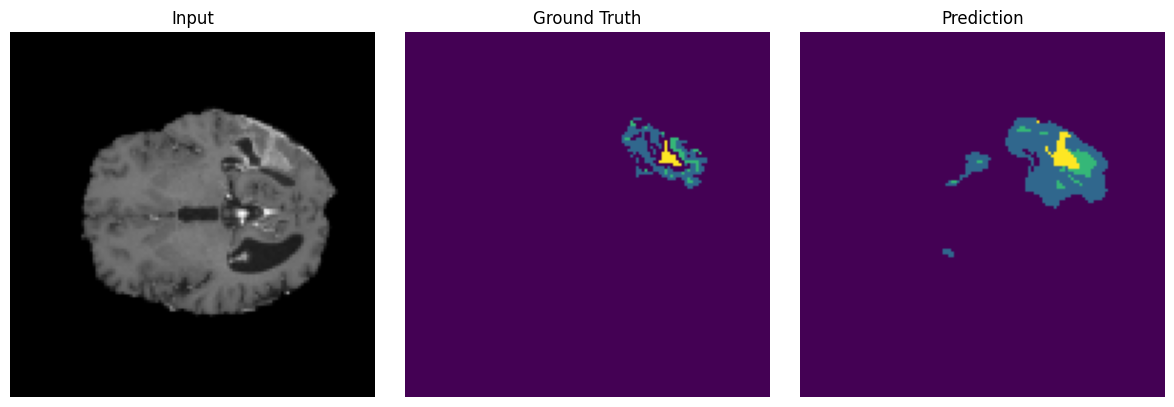

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


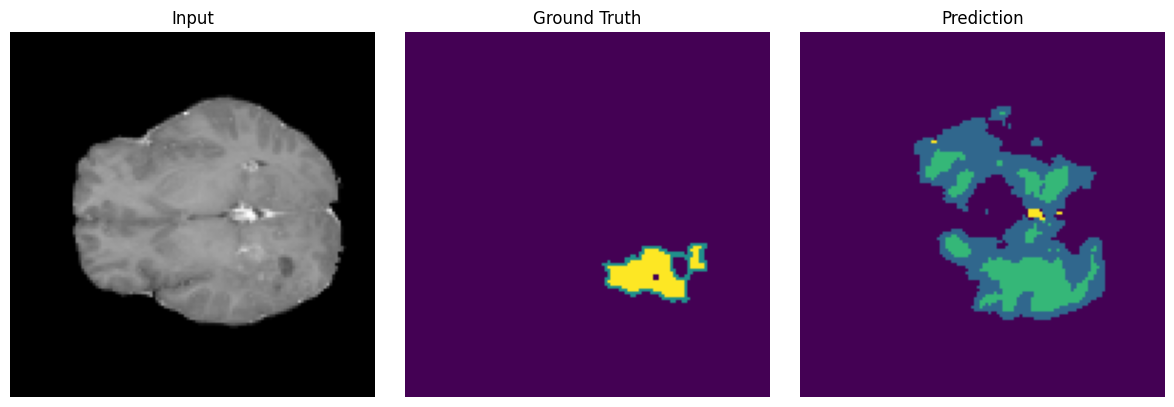

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


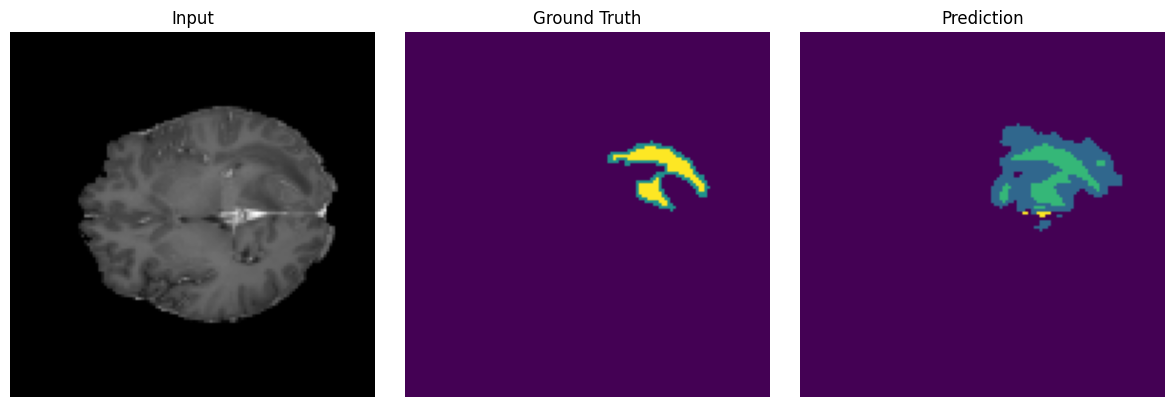

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


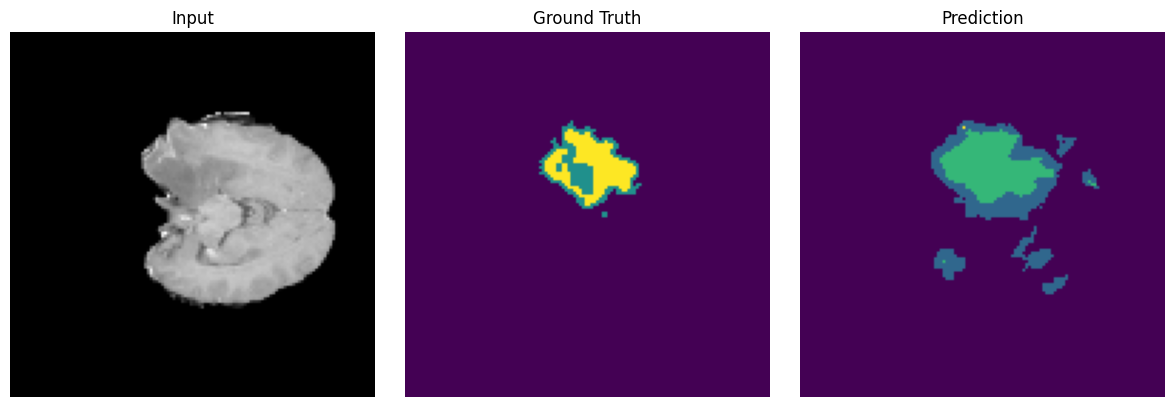

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


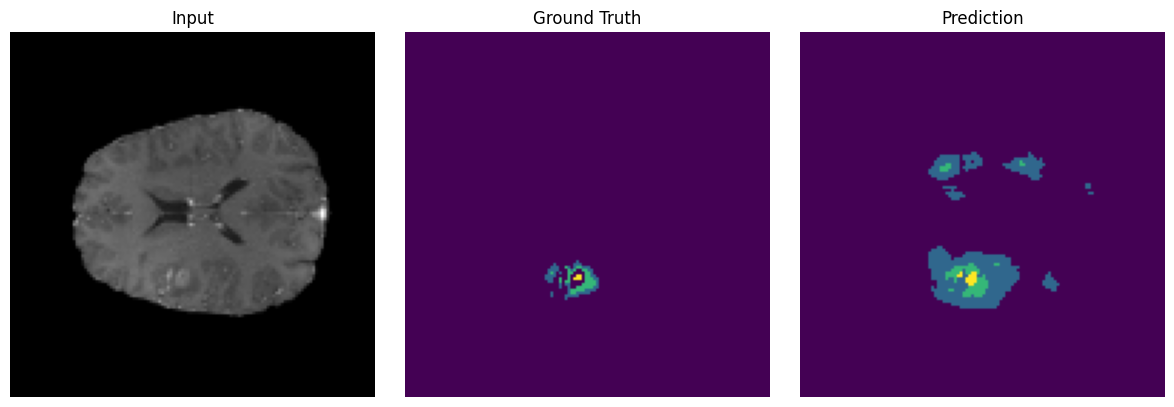

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


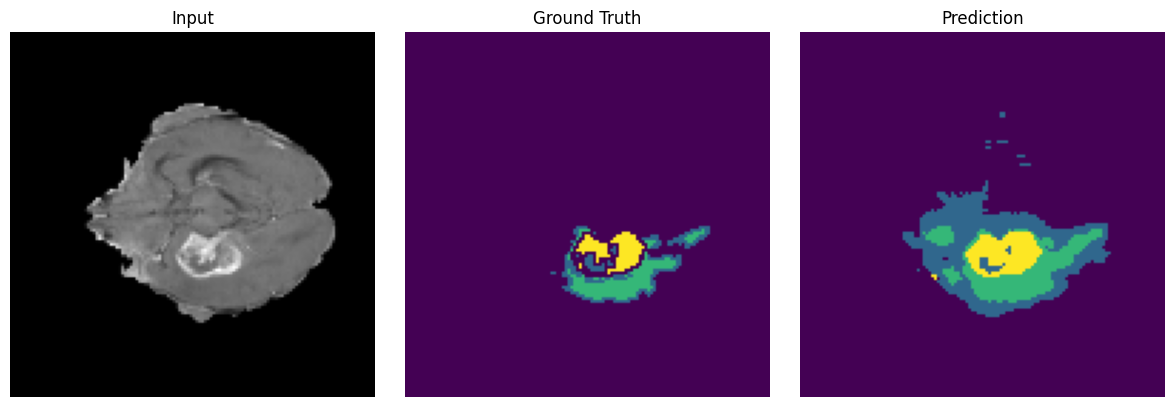

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


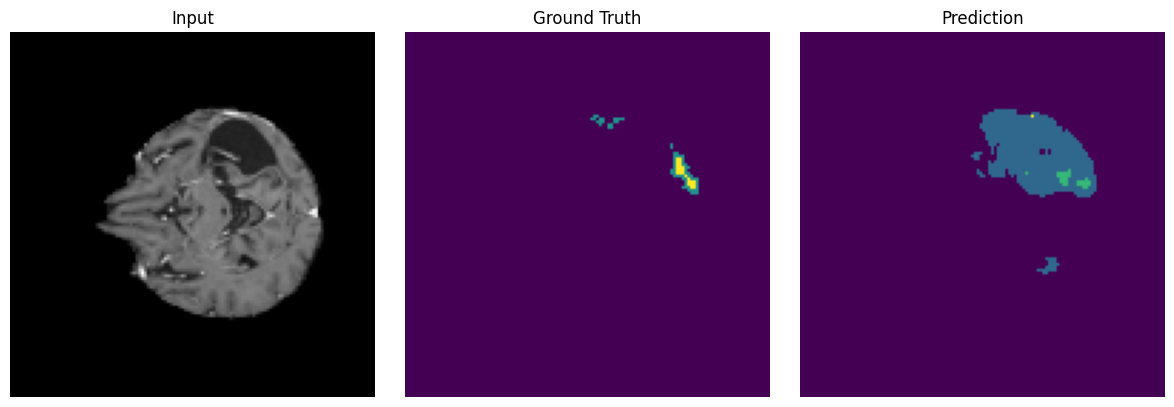

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model with custom loss
model = load_model(
    "unet_weighted_div.h5",
    custom_objects={"weighted_categorical_crossentropy": weighted_categorical_crossentropy}
)

# Test on 30 random samples
num_samples = 30
indices = np.random.choice(len(X_val), num_samples, replace=False)

for i, idx in enumerate(indices):
    sample = X_val[idx:idx+1]  # shape (1, 128, 128, 1)
    true_mask = np.argmax(Y_val[idx], axis=-1)  # shape (128, 128)
    pred = model.predict(sample)
    pred_mask = np.argmax(pred[0], axis=-1)     # shape (128, 128)

    # Plot input, ground truth, prediction
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(sample[0, :, :, 0], cmap='gray')
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='viridis')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='viridis')
    plt.title("Prediction")
    plt.axis('off')

    plt.tight_layout()
    plt.show()